# 0. Preprocessing: time conversion, angles, and outlier handling

This notebook prepares the cleaned dataset used by downstream analyses.

## Inputs

Place raw CSV files in `data/raw/` (preferred):

- `data/raw/EEDA_autonomous_raw_unitvectors.csv`
- `data/raw/EEDA_manual_raw_unitvectors.csv`

The notebook reads all CSV files from `data/raw/` and also supports `raw/` as a fallback location.

## Outputs

Primary output:
- `data/EEDA_cleaned.csv`

Additional intermediate outputs are written under:
- `results/data_cleaning/angles/`
- `results/data_cleaning/outliers/`
- `results/data_cleaning/plots/`

## Run context

Run this notebook from the project root directory so relative paths resolve correctly.

## What this notebook does

1. Loads raw unit-vector data.
2. Converts timestamps to per-UID elapsed time.
3. Detects and excludes UIDs with recording issues.
4. Converts Unity unit vectors to Euler angles.
5. Computes derivatives and additional quality-control metrics.
6. Exports cleaned data for the PCA and subsequent notebooks.

In [1]:
import gc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import dataframe_image as dfi
import os
import math
from pathlib import Path
from  matplotlib.ticker import PercentFormatter
sns.set_style("white")
# sns.set_context("notebook")
sns.set_theme(style="ticks", palette="husl")
# set dask dashboard
import dask
dask.config.set({'dataframe.query-planning': True})
import dask.dataframe as dd
from scipy.spatial.transform import Rotation as R
# pd.options.mode.chained_assignment = None  # default='warn'
from dask.distributed import Client

# Project-wide paths (run notebook from repository root)
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR_CANDIDATES = [
    DATA_DIR / "raw",      # preferred
    PROJECT_ROOT / "raw",  # fallback
]
RAW_DIR = next((p for p in RAW_DIR_CANDIDATES if p.exists()), RAW_DIR_CANDIDATES[0])

DATA_CLEANING_DIR = PROJECT_ROOT / "results" / "data_cleaning"
ANGLES_DIR = DATA_CLEANING_DIR / "angles"
OUTLIERS_DIR = DATA_CLEANING_DIR / "outliers"
PLOTS_DIR = DATA_CLEANING_DIR / "plots"

# Ensure output directories exist
DATA_DIR.mkdir(parents=True, exist_ok=True)
ANGLES_DIR.mkdir(parents=True, exist_ok=True)
OUTLIERS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

client = Client()  # start distributed scheduler locally.
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:63276,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 16
Started: Just now,Total memory: 64.00 GiB
Comm: tcp://127.0.0.1:63292,Total threads: 4
Dashboard: http://127.0.0.1:63298/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:63279,


In [2]:
# Check if the data directory exists
# Preflight check: verify raw input files exist
if not RAW_DIR.exists():
    searched = "\n".join(f" - {p}" for p in RAW_DIR_CANDIDATES)
    raise FileNotFoundError(
        "Missing raw data directory. Checked:\n"
        f"{searched}\n"
        "Create 'data/raw/' (preferred) and place raw CSV files there."
    )

csv_files = sorted(RAW_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in: {RAW_DIR}\n"
        "Add raw CSV files before running preprocessing."
    )

expected_names = {
    "EEDA_autonomous_raw_unitvectors.csv",
    "EEDA_manual_raw_unitvectors.csv",
}
found_names = {p.name for p in csv_files}
missing_expected = sorted(expected_names - found_names)
if missing_expected:
    print("Warning: expected named files not found:", missing_expected)
    print("Continuing because notebook is configured to read all CSV files in the selected raw directory.")

# print(f"Raw directory selected: {RAW_DIR}")
print(f"CSV files found: {len(csv_files)}")
for p in csv_files:
    print(f" - {p.name}")

CSV files found: 2
 - EEDA_autonomous_raw_unitvectors.csv
 - EEDA_manual_raw_unitvectors.csv


### Helper functions for time conversion 
Here’s a step-by-step breakdown of what this function does:

``df.groupby(['uid']):`` This groups the DataFrame by the uid column. Each group now contains all rows that have the same uid.

``.transform(lambda x: (x.index - x.index[0]) / np.timedelta64(1, 's')):`` This applies a transformation to each group separately. The transformation takes the index of each row in the group (which is a timestamp, as implied by the later usage of np.timedelta64), subtracts the index of the first row of the group (i.e., the timestamp of the first row), and divides the result by np.timedelta64(1, 's') to convert the time difference to seconds.

``.TobiiTimeStamp:`` This selects the TobiiTimeStamp column from the transformed DataFrame.
So, in summary, for each uid, the Time_duration column will contain the time elapsed in seconds since the first timestamp of that uid in the TobiiTimeStamp column. This could be useful, for example, to analyze time-series data where you’re interested in the time elapsed since the start of the observation for each uid.

In [4]:
# convert time to seconds from reference time
def time_convert_2(df):
    """This function is taking a DataFrame, with a Unix timestamp column, converting it to datetime objects, using it as the index, creating a new column with time duration and returning the modified DataFrame.
    """
    df['timestamp_REF'] = pd.to_datetime(df.Auto_TobiiTimeStamp,
                                         utc=True,
                                         unit='s',
                                         origin='unix')

    df.set_index('timestamp_REF', inplace=True)
    df['Time_duration'] = (df.groupby(
        ['uid']).transform(lambda x: (x.index - x.index[
            0]) / np.timedelta64(1, 's')).TobiiTimeStamp)
    df = df.reset_index(drop=False)
    return df
# determine the length of the events
def define_event_column(df):
    df['Event'] = 'none'
    
    df.loc[(df['Time_duration'] > 20.81543) &
           (df['Time_duration'] < 30.975586), 'Event'] = 'one'
    df.loc[(df['Time_duration'] > 63.350586) &
           (df['Time_duration'] < 81.875), 'Event'] = 'two'
    df.loc[(df['Time_duration'] > 134.415039) &
           (df['Time_duration'] < 157.28418), 'Event'] = 'three'

    df.loc[(df['Time_duration'] > 188.579102) &
           (df['Time_duration'] < 198.750977), 'Event'] = 'four'
    df.loc[(df['Time_duration'] > 228.447266) &
           (df['Time_duration'] < 243.241211), 'Event'] = 'five'
    df.loc[(df['Time_duration'] > 267.006836) &
           (df['Time_duration'] < 280.178711), 'Event'] = 'six'

    df.loc[(df['Time_duration'] > 325.889648) &
           (df['Time_duration'] < 345.359375), 'Event'] = 'seven'
    df.loc[(df['Time_duration'] > 382.21875) &
           (df['Time_duration'] < 401.822266), 'Event'] = 'eight'
    df.loc[(df['Time_duration'] > 432.363281) &
           (df['Time_duration'] < 447.792969), 'Event'] = 'nine'
    df.loc[(df['Time_duration'] > 464.603516) &
           (df['Time_duration'] < 471.923828), 'Event'] = 'ten'
    
    # Identify before and after event segments
    df.loc[(df['Time_duration'] > 20.81543 - 10) &
           (df['Time_duration'] < 20.81543), 'Event'] = 'one_BE'
    df.loc[(df['Time_duration'] > 30.975586) &
           (df['Time_duration'] < 30.975586 + 10), 'Event'] = 'one_AF'
    
    df.loc[(df['Time_duration'] > 63.350586 - 10) &
           (df['Time_duration'] < 63.350586), 'Event'] = 'two_BE'
    df.loc[(df['Time_duration'] > 81.875) &
           (df['Time_duration'] < 81.875 + 10), 'Event'] = 'two_AF'
    
    df.loc[(df['Time_duration'] > 134.415039 - 10) &
           (df['Time_duration'] < 134.415039), 'Event'] = 'three_BE'
    df.loc[(df['Time_duration'] > 157.28418) &
           (df['Time_duration'] < 157.28418 + 10), 'Event'] = 'three_AF'
    
    df.loc[(df['Time_duration'] > 188.579102 - 10) &
           (df['Time_duration'] < 188.579102), 'Event'] = 'four_BE'
    df.loc[(df['Time_duration'] > 198.750977) &
           (df['Time_duration'] < 198.750977 + 10), 'Event'] = 'four_AF'
    
    df.loc[(df['Time_duration'] > 228.447266 - 10) &
           (df['Time_duration'] < 228.447266), 'Event'] = 'five_BE'
    df.loc[(df['Time_duration'] > 243.241211) &
           (df['Time_duration'] < 243.241211 + 10), 'Event'] = 'five_AF'
    
    df.loc[(df['Time_duration'] > 267.006836 - 10) &
           (df['Time_duration'] < 267.006836), 'Event'] = 'six_BE'
    df.loc[(df['Time_duration'] > 280.178711) &
           (df['Time_duration'] < 280.178711 + 10), 'Event'] = 'six_AF'
    
    df.loc[(df['Time_duration'] > 325.889648 - 10) &
           (df['Time_duration'] < 325.889648), 'Event'] = 'seven_BE'
    df.loc[(df['Time_duration'] > 345.359375) &
           (df['Time_duration'] < 345.359375 + 10), 'Event'] = 'seven_AF'
    
    df.loc[(df['Time_duration'] > 382.21875 - 10) &
           (df['Time_duration'] < 382.21875), 'Event'] = 'eight_BE'
    df.loc[(df['Time_duration'] > 401.822266) &
           (df['Time_duration'] < 401.822266 + 10), 'Event'] = 'eight_AF'
    
    df.loc[(df['Time_duration'] > 432.363281 - 10) &
           (df['Time_duration'] < 432.363281), 'Event'] = 'nine_BE'
    df.loc[(df['Time_duration'] > 447.792969) &
           (df['Time_duration'] < 447.792969 + 10), 'Event'] = 'nine_AF'
    
    df.loc[(df['Time_duration'] > 464.603516 - 10) &
           (df['Time_duration'] < 464.603516), 'Event'] = 'ten_BE'
    df.loc[(df['Time_duration'] > 471.923828) &
           (df['Time_duration'] < 471.923828 + 10), 'Event'] = 'ten_AF'

    return df
# devide events into sub-events
def divide_event_column(df):
    df['Event_inside'] = 'OUT'
    # Event one
    df.loc[(df['Time_duration'] > 20.81543) &
           (df['Time_duration'] <= 24.20215), 'Event_inside'] = 'start'
    df.loc[(df['Time_duration'] > 24.20215) &
           (df['Time_duration'] <= 27.58887), 'Event_inside'] = 'middle'
    df.loc[(df['Time_duration'] > 27.58887) &
           (df['Time_duration'] < 30.975586), 'Event_inside'] = 'end'

    df.loc[(df['Time_duration'] > 63.35058) &
           (df['Time_duration'] <= 69.52539), 'Event_inside'] = 'start'
    df.loc[(df['Time_duration'] > 69.52539) &
           (df['Time_duration'] <= 75.70019), 'Event_inside'] = 'middle'
    df.loc[(df['Time_duration'] > 75.70019) & (df['Time_duration'] < 81.875),
           'Event_inside'] = 'end'

    df.loc[(df['Time_duration'] > 134.415039) &
           (df['Time_duration'] <= 142.038086), 'Event_inside'] = 'start'
    df.loc[(df['Time_duration'] > 142.038086) &
           (df['Time_duration'] <= 149.661133), 'Event_inside'] = 'middle'
    df.loc[(df['Time_duration'] > 149.661133) &
           (df['Time_duration'] < 157.28418), 'Event_inside'] = 'end'

    df.loc[(df['Time_duration'] > 188.579102) &
           (df['Time_duration'] <= 191.969727), 'Event_inside'] = 'start'
    df.loc[(df['Time_duration'] > 191.969727) &
           (df['Time_duration'] <= 195.360352), 'Event_inside'] = 'middle'
    df.loc[(df['Time_duration'] > 195.360352) &
           (df['Time_duration'] < 198.750977), 'Event_inside'] = 'end'

    df.loc[(df['Time_duration'] > 228.447266) &
           (df['Time_duration'] <= 233.378581), 'Event_inside'] = 'start'
    df.loc[(df['Time_duration'] > 233.378581) &
           (df['Time_duration'] <= 238.309896), 'Event_inside'] = 'middle'
    df.loc[(df['Time_duration'] > 238.309896) &
           (df['Time_duration'] < 243.241211), 'Event_inside'] = 'end'

    df.loc[(df['Time_duration'] > 267.00683) &
           (df['Time_duration'] <= 271.397457), 'Event_inside'] = 'start'
    df.loc[(df['Time_duration'] > 271.397457) &
           (df['Time_duration'] <= 275.788084), 'Event_inside'] = 'middle'
    df.loc[(df['Time_duration'] > 275.788084) &
           (df['Time_duration'] < 280.17871), 'Event_inside'] = 'end'

    df.loc[(df['Time_duration'] > 325.889648) &
           (df['Time_duration'] <= 332.37955), 'Event_inside'] = 'start'
    df.loc[(df['Time_duration'] > 332.37955) &
           (df['Time_duration'] <= 338.869466), 'Event_inside'] = 'middle'
    df.loc[(df['Time_duration'] > 338.869466) &
           (df['Time_duration'] < 345.359375), 'Event_inside'] = 'end'

    df.loc[(df['Time_duration'] > 382.21875) &
           (df['Time_duration'] <= 388.75325), 'Event_inside'] = 'start'
    df.loc[(df['Time_duration'] > 388.75325) &
           (df['Time_duration'] <= 395.28776), 'Event_inside'] = 'middle'
    df.loc[(df['Time_duration'] > 395.28776) &
           (df['Time_duration'] < 401.822266), 'Event_inside'] = 'end'

    df.loc[(df['Time_duration'] > 432.363281) &
           (df['Time_duration'] <= 437.50651), 'Event_inside'] = 'start'
    df.loc[(df['Time_duration'] > 437.50651) &
           (df['Time_duration'] <= 442.64973), 'Event_inside'] = 'middle'
    df.loc[(df['Time_duration'] > 442.64973) &
           (df['Time_duration'] < 447.792969), 'Event_inside'] = 'end'

    df.loc[(df['Time_duration'] > 464.603516) &
           (df['Time_duration'] <= 467.04362), 'Event_inside'] = 'start'
    df.loc[(df['Time_duration'] > 467.04362) &
           (df['Time_duration'] <= 469.483724), 'Event_inside'] = 'middle'
    df.loc[(df['Time_duration'] > 469.483724) &
           (df['Time_duration'] < 471.923828), 'Event_inside'] = 'end'

    return df

# 1. Load data

In [5]:
# Load raw unit vectors data from the selected raw folder
df = dd.read_csv(str(RAW_DIR / '*.csv')).compute()

In [6]:
# check the data
df.head()

,UnixTimeStamp,TobiiTimeStamp,HmdPosition_x,HmdPosition_y,HmdPosition_z,NoseVector_x,NoseVector_y,NoseVector_z,HmdRotation_x,HmdRotation_y,...,uid,EyeDirectionCombinedLocal_x,EyeDirectionCombinedLocal_y,EyeDirectionCombinedLocal_z,SteeringInput,AcellerationInput,BrakeInput,Auto_TobiiTimeStamp,Condition,Pupil_Dilation_mean
0,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,0.608628,...,02652779cbca4679bd48ebc0a0b7af77,0.076767,-0.316071,0.945618,-0.00381,0.0,0.0,10599.665039,Autonomous,4.402054
1,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,0.608628,...,02652779cbca4679bd48ebc0a0b7af77,0.076767,-0.316071,0.945618,-0.00381,0.0,0.0,10599.686523,Autonomous,4.402054
2,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,0.608628,...,02652779cbca4679bd48ebc0a0b7af77,0.076767,-0.316071,0.945618,-0.00381,0.0,0.0,10599.699219,Autonomous,4.402054
3,1.634728e+09,0.0,162.128281,376.970490,434.783386,0.959486,-0.065430,0.274055,0.020934,0.602108,...,02652779cbca4679bd48ebc0a0b7af77,0.076767,-0.316071,0.945618,-0.00381,0.0,0.0,10599.721680,Autonomous,4.402054
4,1.634728e+09,0.0,162.625748,376.962219,434.915253,0.959160,-0.065371,0.275206,0.021013,0.601627,...,02652779cbca4679bd48ebc0a0b7af77,0.076767,-0.316071,0.945618,-0.00381,0.0,0.0,10599.743164,Autonomous,4.402054


In [7]:
df.columns

Index(['UnixTimeStamp', 'TobiiTimeStamp', 'HmdPosition_x', 'HmdPosition_y',
       'HmdPosition_z', 'NoseVector_x', 'NoseVector_y', 'NoseVector_z',
       'HmdRotation_x', 'HmdRotation_y', 'HmdRotation_z', 'HmdRotation_w',
       'CarPosition_x', 'CarPosition_y', 'CarPosition_z', 'CarRotation_x',
       'CarRotation_y', 'CarRotation_z', 'CarRotation_w', 'uid',
       'EyeDirectionCombinedLocal_x', 'EyeDirectionCombinedLocal_y',
       'EyeDirectionCombinedLocal_z', 'SteeringInput', 'AcellerationInput',
       'BrakeInput', 'Auto_TobiiTimeStamp', 'Condition',
       'Pupil_Dilation_mean'],
      dtype='object')

## 2. Applying time conversion pipeline

In [8]:
# apply time conversion pipeline
df_time = df.copy().pipe(time_convert_2).pipe(define_event_column).pipe(divide_event_column)
df_time

,timestamp_REF,UnixTimeStamp,TobiiTimeStamp,HmdPosition_x,HmdPosition_y,HmdPosition_z,NoseVector_x,NoseVector_y,NoseVector_z,HmdRotation_x,...,EyeDirectionCombinedLocal_z,SteeringInput,AcellerationInput,BrakeInput,Auto_TobiiTimeStamp,Condition,Pupil_Dilation_mean,Time_duration,Event,Event_inside
0,1970-01-01 02:56:39.665039062+00:00,1.634728e+09,0.000000,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,0.945618,-0.00381,0.0,0.0,10599.665039,Autonomous,4.402054,0.000000,none,OUT
1,1970-01-01 02:56:39.686523437+00:00,1.634728e+09,0.000000,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,0.945618,-0.00381,0.0,0.0,10599.686523,Autonomous,4.402054,0.021484,none,OUT
2,1970-01-01 02:56:39.699218750+00:00,1.634728e+09,0.000000,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,0.945618,-0.00381,0.0,0.0,10599.699219,Autonomous,4.402054,0.034180,none,OUT
3,1970-01-01 02:56:39.721679687+00:00,1.634728e+09,0.000000,162.128281,376.970490,434.783386,0.959486,-0.065430,0.274055,0.020934,...,0.945618,-0.00381,0.0,0.0,10599.721680,Autonomous,4.402054,0.056641,none,OUT
4,1970-01-01 02:56:39.743164062+00:00,1.634728e+09,0.000000,162.625748,376.962219,434.915253,0.959160,-0.065371,0.275206,0.021013,...,0.945618,-0.00381,0.0,0.0,10599.743164,Autonomous,4.402054,0.078125,none,OUT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7493199,1970-01-01 03:04:33.920898437+00:00,1.634728e+09,11596.947266,-1498.483643,131.260544,2379.344971,0.622703,-0.114496,0.774036,0.066435,...,0.998505,0.00000,1.0,0.0,11073.920898,Manual,3.538361,474.255859,ten_AF,OUT
7493200,1970-01-01 03:04:33.943359375+00:00,1.634728e+09,11596.958984,-1498.483643,131.260651,2379.344971,0.623641,-0.113893,0.773369,0.066106,...,0.998505,0.00000,1.0,0.0,11073.943359,Manual,3.547325,474.278320,ten_AF,OUT
7493201,1970-01-01 03:04:33.954101562+00:00,1.634728e+09,11596.981445,-1497.612793,131.179337,2380.383301,0.626079,-0.110740,0.771856,0.064661,...,0.998627,0.00000,1.0,0.0,11073.954102,Manual,3.573761,474.289062,ten_AF,OUT
7493202,1970-01-01 03:04:33.976562500+00:00,1.634728e+09,11596.981445,-1497.612793,131.179337,2380.383301,0.626079,-0.110740,0.771856,0.064661,...,0.998627,0.00000,1.0,0.0,11073.976562,Manual,3.573761,474.311523,ten_AF,OUT


# 3. Exclude bad recordings 
Here we exclude UIDs with only one unique or few consecutive numbers across entire recording

In [9]:
# Count the amount of unique values in each column per uid
df_unique_values = df_time.groupby('uid').nunique().reset_index()
df_unique_values

,uid,timestamp_REF,UnixTimeStamp,TobiiTimeStamp,HmdPosition_x,HmdPosition_y,HmdPosition_z,NoseVector_x,NoseVector_y,NoseVector_z,...,EyeDirectionCombinedLocal_z,SteeringInput,AcellerationInput,BrakeInput,Auto_TobiiTimeStamp,Condition,Pupil_Dilation_mean,Time_duration,Event,Event_inside
0,017397ca31114170abc2ff61a217460b,24577,19890,19880,19478,19482,19132,19867,19884,19882,...,3114,1884,153,110,24577,1,18496,24577,31,4
1,01834492f844419681793c107d49ed71,24577,12597,12488,12333,12412,12163,12585,12592,12594,...,2988,1074,232,157,24577,1,12059,24577,31,4
2,01a81ed75f3548249a0b378943e39f6b,24577,13531,13126,13374,13414,13293,13522,13528,13527,...,5046,1218,255,143,24577,1,13107,24577,31,4
3,020e858f532e458d88749fa3191fc8cb,24577,13936,13590,13919,13883,13899,13930,13929,13922,...,3074,1307,157,105,24577,1,13574,24577,31,4
4,02652779cbca4679bd48ebc0a0b7af77,24577,17751,16741,17339,17338,17022,17742,17749,17741,...,7293,1021,50,44,24577,1,17255,24577,31,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,fe568108ba4742cb974bb62748627b05,24577,13422,13167,13276,13302,13166,13409,13420,13414,...,3628,1052,158,132,24577,1,12876,24577,31,4
301,ff3710a0ba6245d6be18e2925a4a373e,24577,15344,15033,15318,15268,15272,15334,15341,15332,...,2922,1266,162,151,24577,1,14937,24577,31,4
302,ffb7f9e65f664c1fab6591d9b2afc085,24577,13820,13014,13511,13618,13381,13815,13818,13814,...,5529,1252,164,117,24577,1,13543,24577,31,4
303,ffbd3ee1986747d4aa98a8c79c5a8097,24577,13726,13025,13569,13590,13471,13718,13724,13722,...,4250,992,153,133,24577,1,13277,24577,31,4


In [10]:
# Melt all desired columns into a single "measurement" columns
# The "count" column will contain the count of unique values
df_unique_head_car_melt = df_unique_values[['uid','HmdPosition_x','HmdPosition_y','HmdPosition_z','NoseVector_x','NoseVector_y','NoseVector_z','HmdRotation_x','HmdRotation_y','HmdRotation_z','HmdRotation_w','CarPosition_x','CarPosition_y','CarPosition_z','CarRotation_x','CarRotation_y','CarRotation_z','CarRotation_w','EyeDirectionCombinedLocal_x','EyeDirectionCombinedLocal_y','EyeDirectionCombinedLocal_z']].melt('uid',var_name='measurement',value_name='count')
df_unique_head_car_melt.head(5)

,uid,measurement,count
0,017397ca31114170abc2ff61a217460b,HmdPosition_x,19478
1,01834492f844419681793c107d49ed71,HmdPosition_x,12333
2,01a81ed75f3548249a0b378943e39f6b,HmdPosition_x,13374
3,020e858f532e458d88749fa3191fc8cb,HmdPosition_x,13919
4,02652779cbca4679bd48ebc0a0b7af77,HmdPosition_x,17339


In [11]:
# Melt steering separately for proper visualization
df_unique_eye_melt = df_unique_values[['uid','SteeringInput']].melt('uid',var_name='measurement',value_name='count')
df_unique_eye_melt.head(5)

,uid,measurement,count
0,017397ca31114170abc2ff61a217460b,SteeringInput,1884
1,01834492f844419681793c107d49ed71,SteeringInput,1074
2,01a81ed75f3548249a0b378943e39f6b,SteeringInput,1218
3,020e858f532e458d88749fa3191fc8cb,SteeringInput,1307
4,02652779cbca4679bd48ebc0a0b7af77,SteeringInput,1021


/Users/johnmadrid/dev/phd_main/lib/python3.11/site-packages/seaborn/categorical.py:3370: UserWarning: 5.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


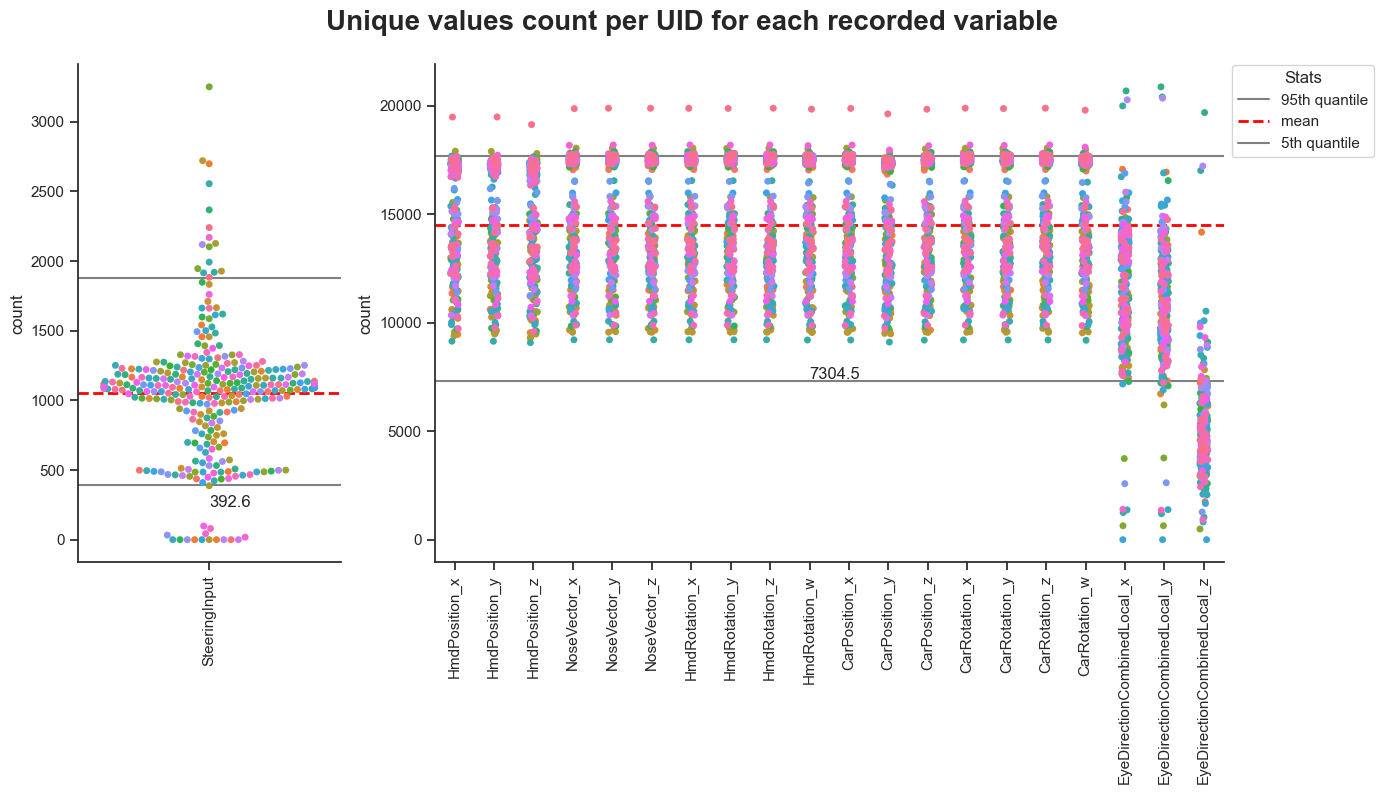

In [12]:
# visualize unique count per recorded variable
f, (a0, a1) = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={'width_ratios': [1, 3]})
f.suptitle("Unique values count per UID for each recorded variable", 
           fontsize=20, y=0.99, fontweight='bold')
sns.swarmplot(df_unique_eye_melt, x='measurement', y='count',
              hue='uid', ax=a0,legend=False)
a0.axhline(y = np.percentile(df_unique_eye_melt['count'], [5]), color='gray')
a0.axhline(y = np.average(df_unique_eye_melt['count']), linestyle='--', 
           linewidth = 2, color='r')
a0.axhline(y = np.percentile(df_unique_eye_melt['count'], [95]), color='gray')
a0.set_xlabel('')
a0.tick_params(axis='x', rotation=90)
q2 = np.percentile(df_unique_eye_melt['count'], [5])
a0.text(0, q2 - 160,str(q2)[1:-1],rotation=0)
# ax1.text(0.1, 0.5, 'Begin text', horizontalalignment='center', verticalalignment='center', transform=ax1.transAxes)


g2 = sns.stripplot(df_unique_head_car_melt, x='measurement', y='count', 
                   hue='uid', ax=a1,legend=False)
# add 5th and 95th quantile lines
a1.axhline(y = np.percentile(df_unique_head_car_melt['count'], [95]), 
           color='gray',label='95th quantile')
a1.axhline(y = np.average(df_unique_head_car_melt['count']), linestyle='--', 
           linewidth = 2, color='r',label='mean')
a1.axhline(y = np.percentile(df_unique_head_car_melt['count'], [5]), 
           color='gray', label='5th quantile')
q1 = np.percentile(df_unique_head_car_melt['count'], [5])
plt.text(9, q1+100,str(q1)[1:-1],rotation=0)
a1.set_xlabel('')
a1.tick_params(axis='x', rotation=90)
plt.legend()
plt.legend(title='Stats', bbox_to_anchor=(1.01, 1), loc=2,borderaxespad=.05,markerscale=2)
sns.despine()
plt.tight_layout()
# plt.savefig('new_plots/unique_values_count_' + '.png', dpi=300)
plt.show()

In [13]:
# UIDs that contain only few unique value across all recording duration for
# any of this variables
df_excluded_eye = df_unique_values[(df_unique_values['EyeDirectionCombinedLocal_x'] < 6700)|
                (df_unique_values['EyeDirectionCombinedLocal_y'] < 6700)].reset_index()

df_excluded_steer = df_unique_values[df_unique_values['SteeringInput'] < 50].reset_index()

In [14]:
# list participants' UID to exclude
excluded_uid_eye = df_excluded_eye['uid'].tolist()
excluded_uid_steer = df_excluded_steer['uid'].tolist()

In [15]:
# eye recording issues
df_excluded_uids_eye = df_time[df_time['uid'].isin(excluded_uid_eye)]
# steer recoding issues
df_excluded_uids_steer = df_time[df_time['uid'].isin(excluded_uid_steer)]

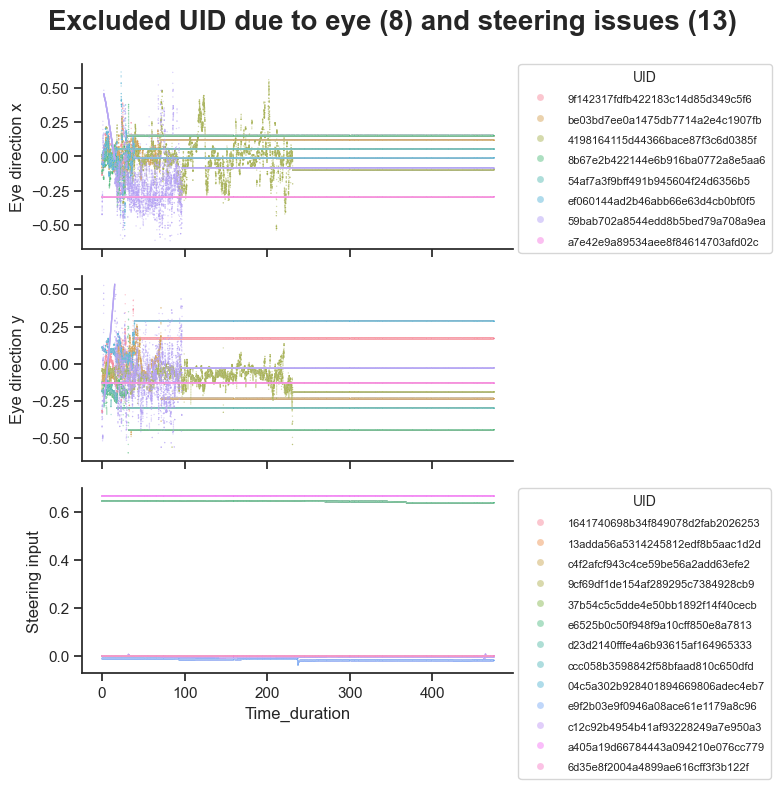

In [16]:
fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
fig.suptitle("Excluded UID due to eye (8) and steering issues (13)", 
           fontsize=20, y=0.99, fontweight='bold')
# eye issues
gfg = sns.scatterplot(data=df_excluded_uids_eye, x="Time_duration",y='EyeDirectionCombinedLocal_x', 
                      hue='uid', s=1, alpha=0.4, ax=ax[0])
ax[0].set_ylabel('Eye direction x')
ax[0].legend(title='UID', bbox_to_anchor=(1.01, 1), loc=2,borderaxespad=.05,markerscale=5)
sns.scatterplot(data=df_excluded_uids_eye, x="Time_duration",y='EyeDirectionCombinedLocal_y',
                hue='uid', s=1, alpha=0.4, ax=ax[1],legend=False)
ax[1].set_ylabel('Eye direction y')

# legend 
plt.setp(gfg.get_legend().get_texts(), fontsize='8')  
plt.setp(gfg.get_legend().get_title(), fontsize='10')
# steering issues
g3 = sns.scatterplot(data=df_excluded_uids_steer, x="Time_duration",y='SteeringInput', 
                hue='uid', s=1, alpha=0.4, ax=ax[2])
ax[2].legend(title='UID', bbox_to_anchor=(1.01, 1), loc=2,borderaxespad=.05,markerscale=5)
ax[2].set_ylabel('Steering input')
# legend 
plt.setp(g3.get_legend().get_texts(), fontsize='8')  
plt.setp(g3.get_legend().get_title(), fontsize='10')
plt.tight_layout()
sns.despine()
# plt.savefig('new_plots/excluded_uid_' + '.png', dpi=300)
plt.show()

## Exclude identified UIDs

In [17]:
# identify all excluded uids with eye and steering issues
df_excluded = df_unique_values[(df_unique_values['EyeDirectionCombinedLocal_x'] < 6700)|
                               (df_unique_values['EyeDirectionCombinedLocal_y'] < 6700)|
                               (df_unique_values['SteeringInput'] < 50)].reset_index()

all_excluded_uids_list = df_excluded['uid'].tolist()
all_excluded_uids_list

['04c5a302b928401894669806adec4eb7',
 '13adda56a5314245812edf8b5aac1d2d',
 '1641740698b34f849078d2fab2026253',
 '37b54c5c5dde4e50bb1892f14f40cecb',
 '4198164115d44366bace87f3c6d0385f',
 '54af7a3f9bff491b945604f24d6356b5',
 '59bab702a8544edd8b5bed79a708a9ea',
 '6d35e8f2004a4899ae616cff3f3b122f',
 '8b67e2b422144e6b916ba0772a8e5aa6',
 '9cf69df1de154af289295c7384928cb9',
 '9f142317fdfb422183c14d85d349c5f6',
 'a405a19d66784443a094210e076cc779',
 'a7e42e9a89534aee8f84614703afd02c',
 'be03bd7ee0a1475db7714a2e4c1907fb',
 'c12c92b4954b41af93228249a7e950a3',
 'c4f2afcf943c4ce59be56a2add63efe2',
 'ccc058b3598842f58bfaad810c650dfd',
 'd23d2140fffe4a6b93615af164965333',
 'e6525b0c50f948f9a10cff850e8a7813',
 'e9f2b03e9f0946a08ace61e1179a8c96',
 'ef060144ad2b46abb66e63d4cb0bf0f5']

In [18]:
print(f"Total UIDs with recording issues: {len(all_excluded_uids_list)}")

Total UIDs with recording issues: 21


In [19]:
# double check that time converted df did exclude all UIDs
# Reason: isin() sometimes does not work properly
df_after_excluded_uid = df_time[~df_time['uid'].isin(all_excluded_uids_list)].reset_index(drop=True)
df_after_excluded_uid

,timestamp_REF,UnixTimeStamp,TobiiTimeStamp,HmdPosition_x,HmdPosition_y,HmdPosition_z,NoseVector_x,NoseVector_y,NoseVector_z,HmdRotation_x,...,EyeDirectionCombinedLocal_z,SteeringInput,AcellerationInput,BrakeInput,Auto_TobiiTimeStamp,Condition,Pupil_Dilation_mean,Time_duration,Event,Event_inside
0,1970-01-01 02:56:39.665039062+00:00,1.634728e+09,0.000000,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,0.945618,-0.00381,0.0,0.0,10599.665039,Autonomous,4.402054,0.000000,none,OUT
1,1970-01-01 02:56:39.686523437+00:00,1.634728e+09,0.000000,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,0.945618,-0.00381,0.0,0.0,10599.686523,Autonomous,4.402054,0.021484,none,OUT
2,1970-01-01 02:56:39.699218750+00:00,1.634728e+09,0.000000,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,0.945618,-0.00381,0.0,0.0,10599.699219,Autonomous,4.402054,0.034180,none,OUT
3,1970-01-01 02:56:39.721679687+00:00,1.634728e+09,0.000000,162.128281,376.970490,434.783386,0.959486,-0.065430,0.274055,0.020934,...,0.945618,-0.00381,0.0,0.0,10599.721680,Autonomous,4.402054,0.056641,none,OUT
4,1970-01-01 02:56:39.743164062+00:00,1.634728e+09,0.000000,162.625748,376.962219,434.915253,0.959160,-0.065371,0.275206,0.021013,...,0.945618,-0.00381,0.0,0.0,10599.743164,Autonomous,4.402054,0.078125,none,OUT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6977082,1970-01-01 03:04:33.920898437+00:00,1.634728e+09,11596.947266,-1498.483643,131.260544,2379.344971,0.622703,-0.114496,0.774036,0.066435,...,0.998505,0.00000,1.0,0.0,11073.920898,Manual,3.538361,474.255859,ten_AF,OUT
6977083,1970-01-01 03:04:33.943359375+00:00,1.634728e+09,11596.958984,-1498.483643,131.260651,2379.344971,0.623641,-0.113893,0.773369,0.066106,...,0.998505,0.00000,1.0,0.0,11073.943359,Manual,3.547325,474.278320,ten_AF,OUT
6977084,1970-01-01 03:04:33.954101562+00:00,1.634728e+09,11596.981445,-1497.612793,131.179337,2380.383301,0.626079,-0.110740,0.771856,0.064661,...,0.998627,0.00000,1.0,0.0,11073.954102,Manual,3.573761,474.289062,ten_AF,OUT
6977085,1970-01-01 03:04:33.976562500+00:00,1.634728e+09,11596.981445,-1497.612793,131.179337,2380.383301,0.626079,-0.110740,0.771856,0.064661,...,0.998627,0.00000,1.0,0.0,11073.976562,Manual,3.573761,474.311523,ten_AF,OUT


## Final participants included

In [20]:
# Excluded UIDs count
uids_left = df_after_excluded_uid['uid'].nunique()
uids_condition = df_after_excluded_uid.groupby('Condition')['uid'].nunique()
print(f'Total initial UIDs: {df["uid"].nunique()}')
print(f'Total UIDs after cleaning: {uids_left}')
print(f'Total excluded UIDs: {df["uid"].nunique()-uids_left}')
print('UIDs per condition: ' + f'\n {uids_condition}')

Total initial UIDs: 305
Total UIDs after cleaning: 284
Total excluded UIDs: 21
UIDs per condition: 
 Condition
Autonomous    153
Manual        131
Name: uid, dtype: int64


# 4. Unity Unit Vectors to Euler angles
## 4.1 Eye horizontal and vertical angles

In [21]:
def eye_h_v_angles(df):
    # df.reset_index(inplace=False)
    """This function converts the eye direction unit vectors (x, y, z) 
    into Euler angles.
    """
    # Horizontal eye angles 
    df['eye_theta_h'] = np.degrees(np.arctan2(df['EyeDirectionCombinedLocal_x'], df['EyeDirectionCombinedLocal_z']))
    # Vertical eye angles
    df['eye_theta_v'] = np.degrees(np.arctan2(df['EyeDirectionCombinedLocal_y'], df['EyeDirectionCombinedLocal_z']))
    return df

## 4.2 Calculating/deducting Car & Head rotation (using SciPy)

In [22]:
from scipy.spatial.transform import Rotation as R
# Calculates the local direction as quaternion from a global quaternion and it's parent quaternion using the scipy.spatial.transform.Rotation package
def global_to_local(global_quaternion, parent_global_quaternion):
    # Inverse of the parent's global rotation
    parent_inverse = R.from_quat(parent_global_quaternion).inv()

    # Combine the global and parent inverse rotations
    local_quaternion = R.from_quat(global_quaternion) * parent_inverse

    return local_quaternion.as_quat()

## 4.3 Quaternion to Euler Angles 

In [23]:
def quaternion_to_euler_for_unity3D(quaternion):
    r = R.from_quat(quaternion)
    euler_angles = r.as_euler('zxy')
    return euler_angles

Extracts the quaternion for the car rotation (global) and head rotation (global) from a given dataset row

In [ ]:
# def row_to_quaternion(row):
#     """Extracts the quaternion for the car rotation (global) and head rotation (global) from a given dataset row
#     :param row: a vector containing the car rotation (global) and head rotation (global)"""
#     car_quaternion = np.array([
#         row['CarRotation_x'], row['CarRotation_y'], 
#         row['CarRotation_z'], row['CarRotation_w']
#     ])
#     head_quaternion = np.array([
#         row['HmdRotation_x'], row['HmdRotation_y'], 
#         row['HmdRotation_z'], row['HmdRotation_w']
#     ])
#     return car_quaternion, head_quaternion

In [24]:
# Extract yaw, pitch, roll for the car (global rotation in degrees against world)
def calculate_yaw_pitch_roll_car(df):
    # car_quaternion, _ = row_to_quaternion(row)
    car_quaternion = df[['CarRotation_x','CarRotation_y','CarRotation_z','CarRotation_w']].values
    euler_angles = quaternion_to_euler_for_unity3D(car_quaternion)
    
    # Euler angles for Unity 3D are extracted in z-x-y order representing roll, pitch, and yaw in that order
    roll_degrees = np.degrees(euler_angles[:,0])
    pitch_degrees = np.degrees(euler_angles[:,1])
    yaw_degrees = np.degrees(euler_angles[:,2])
    
    df['CarYaw_degrees'] = yaw_degrees
    df['CarPitch_degrees'] = pitch_degrees
    df['CarRoll_degrees'] = roll_degrees
    return df

# Extract yaw, pitch, roll for the head (local rotation in degrees given car's global rotation)
def calculate_yaw_pitch_roll_head_local(df):
    # car_quaternion, head_quaternion = row_to_quaternion(row)
    car_quaternion = df[['CarRotation_x','CarRotation_y','CarRotation_z','CarRotation_w']].values
    head_quaternion = df[['HmdRotation_x','HmdRotation_y','HmdRotation_z','HmdRotation_w']].values

    # Euler angles for Unity 3D are extracted in z-x-y order representing roll, pitch, and yaw in that order
    euler_angles = quaternion_to_euler_for_unity3D(global_to_local(head_quaternion, car_quaternion))
    
    roll_degrees = np.degrees(euler_angles[:,0])
    pitch_degrees = np.degrees(euler_angles[:,1])
    yaw_degrees = np.degrees(euler_angles[:,2])
    
    df['RelativeHeadYaw_degrees'] = yaw_degrees
    df['RelativeHeadPitch_degrees'] = pitch_degrees
    df['RelativeHeadRoll_degrees'] = roll_degrees
    return df

In [25]:
# Extract yaw, pitch, roll for the car (global rotation in degrees against world)
def calculate_yaw_pitch_roll_head(df):
    # _, head_quaternion = row_to_quaternion(row)
    head_quaternion = df[['HmdRotation_x','HmdRotation_y','HmdRotation_z','HmdRotation_w']].values
    euler_angles = quaternion_to_euler_for_unity3D(head_quaternion)
    
    # Euler angles for Unity 3D are extracted in z-x-y order representing roll, pitch, and yaw in that order
    roll_degrees = np.degrees(euler_angles[:,0])
    pitch_degrees = np.degrees(euler_angles[:,1])
    yaw_degrees = np.degrees(euler_angles[:,2])
    
    df['GlobalHeadYaw_degrees'] = yaw_degrees
    df['GlobalHeadPitch_degrees'] = pitch_degrees
    df['GlobalHeadRoll_degrees'] = roll_degrees
    return df

## 4.4 Steering input to degrees

In [26]:
# just to check the steering input values because they should be in degrees
def steer_to_degrees(df):
    """
    Converts a df column with steering imput (in radian) to angles in degrees
    :param df: 
    :return: a df column with steering angle in degrees
    """
    # df_combined['streerDegree2'] = df_combined['SteeringInput'] * (180/math.pi)
    df['steeringDegree'] = np.rad2deg(df['SteeringInput'])
    return df

# 5. Applying angles calculations
After excluding all uid with recording issues (eye=8, steer=13,total = 21), we apply the angles calculation functions to the eye (z,y,x) head  (x,y,z,w), car (x,y,z,w), unit vectors and steering wheel componen which as measured in radians.

In [27]:
# Final dataframe with converted time, events identified, and excluded bad recordings.
df_after_excluded_uid.head()

,timestamp_REF,UnixTimeStamp,TobiiTimeStamp,HmdPosition_x,HmdPosition_y,HmdPosition_z,NoseVector_x,NoseVector_y,NoseVector_z,HmdRotation_x,...,EyeDirectionCombinedLocal_z,SteeringInput,AcellerationInput,BrakeInput,Auto_TobiiTimeStamp,Condition,Pupil_Dilation_mean,Time_duration,Event,Event_inside
0,1970-01-01 02:56:39.665039062+00:00,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,0.945618,-0.00381,0.0,0.0,10599.665039,Autonomous,4.402054,0.000000,none,OUT
1,1970-01-01 02:56:39.686523437+00:00,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,0.945618,-0.00381,0.0,0.0,10599.686523,Autonomous,4.402054,0.021484,none,OUT
2,1970-01-01 02:56:39.699218750+00:00,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,0.945618,-0.00381,0.0,0.0,10599.699219,Autonomous,4.402054,0.034180,none,OUT
3,1970-01-01 02:56:39.721679687+00:00,1.634728e+09,0.0,162.128281,376.970490,434.783386,0.959486,-0.065430,0.274055,0.020934,...,0.945618,-0.00381,0.0,0.0,10599.721680,Autonomous,4.402054,0.056641,none,OUT
4,1970-01-01 02:56:39.743164062+00:00,1.634728e+09,0.0,162.625748,376.962219,434.915253,0.959160,-0.065371,0.275206,0.021013,...,0.945618,-0.00381,0.0,0.0,10599.743164,Autonomous,4.402054,0.078125,none,OUT


In [ ]:
# Convert pandas dataframe to dask dataframe when using DASK
# ddf = dd.from_pandas(df_after_excluded_uid)
# ddf_time = ddf.repartition(partition_size="100MB")
# ddf_time.memory_usage().sum().compute()

In [28]:
# Apply angles functions on cleaned 
df_angles = df_after_excluded_uid.copy().pipe(steer_to_degrees).pipe(eye_h_v_angles).pipe(calculate_yaw_pitch_roll_car).pipe(calculate_yaw_pitch_roll_head).pipe(calculate_yaw_pitch_roll_head_local)

In [29]:
df_angles.head()

,timestamp_REF,UnixTimeStamp,TobiiTimeStamp,HmdPosition_x,HmdPosition_y,HmdPosition_z,NoseVector_x,NoseVector_y,NoseVector_z,HmdRotation_x,...,eye_theta_v,CarYaw_degrees,CarPitch_degrees,CarRoll_degrees,GlobalHeadYaw_degrees,GlobalHeadPitch_degrees,GlobalHeadRoll_degrees,RelativeHeadYaw_degrees,RelativeHeadPitch_degrees,RelativeHeadRoll_degrees
0,1970-01-01 02:56:39.665039062+00:00,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,-18.482088,74.869658,0.431839,0.279153,75.002586,3.761673,-0.852370,0.181122,-0.221202,-3.509586
1,1970-01-01 02:56:39.686523437+00:00,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,-18.482088,74.869658,0.431839,0.279153,75.002586,3.761673,-0.852370,0.181122,-0.221202,-3.509586
2,1970-01-01 02:56:39.699218750+00:00,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,-18.482088,74.869658,0.431839,0.279153,75.002586,3.761673,-0.852370,0.181122,-0.221202,-3.509586
3,1970-01-01 02:56:39.721679687+00:00,1.634728e+09,0.0,162.128281,376.970490,434.783386,0.959486,-0.065430,0.274055,0.020934,...,-18.482088,74.807721,0.439612,0.262806,74.059228,3.751541,-0.989276,-0.692284,-0.338176,-3.524178
4,1970-01-01 02:56:39.743164062+00:00,1.634728e+09,0.0,162.625748,376.962219,434.915253,0.959160,-0.065371,0.275206,0.021013,...,-18.482088,74.783168,0.456957,0.254261,73.990561,3.748174,-0.972826,-0.737856,-0.318037,-3.497768


In [30]:
# OPTIONAL: Save angles dataframe
# df_angles.to_csv(ANGLES_DIR / "EEDA_angles_Autonomous_Manual.csv", index=False)

## Visualize eye, head, and car angles per condition

In [31]:
df_angles.columns

Index(['timestamp_REF', 'UnixTimeStamp', 'TobiiTimeStamp', 'HmdPosition_x',
       'HmdPosition_y', 'HmdPosition_z', 'NoseVector_x', 'NoseVector_y',
       'NoseVector_z', 'HmdRotation_x', 'HmdRotation_y', 'HmdRotation_z',
       'HmdRotation_w', 'CarPosition_x', 'CarPosition_y', 'CarPosition_z',
       'CarRotation_x', 'CarRotation_y', 'CarRotation_z', 'CarRotation_w',
       'uid', 'EyeDirectionCombinedLocal_x', 'EyeDirectionCombinedLocal_y',
       'EyeDirectionCombinedLocal_z', 'SteeringInput', 'AcellerationInput',
       'BrakeInput', 'Auto_TobiiTimeStamp', 'Condition', 'Pupil_Dilation_mean',
       'Time_duration', 'Event', 'Event_inside', 'steeringDegree',
       'eye_theta_h', 'eye_theta_v', 'CarYaw_degrees', 'CarPitch_degrees',
       'CarRoll_degrees', 'GlobalHeadYaw_degrees', 'GlobalHeadPitch_degrees',
       'GlobalHeadRoll_degrees', 'RelativeHeadYaw_degrees',
       'RelativeHeadPitch_degrees', 'RelativeHeadRoll_degrees'],
      dtype='object')

In [32]:
df_angles['Condition'].unique()

array(['Autonomous', 'Manual'], dtype=object)

In [34]:
# Split df based on condition
df_manual = df_angles[df_angles['Condition']=='Manual']
df_autonomous = df_angles[df_angles['Condition']=='Autonomous']

# Generate 50 random UIDs per condition
df_manual_sample = df_manual[df_manual['uid'].isin(np.random.choice(df_manual['uid'].unique(), 50, replace=False))]
df_autonomous_sample = df_autonomous[df_autonomous['uid'].isin(np.random.choice(df_autonomous['uid'].unique(), 50, replace=False))]

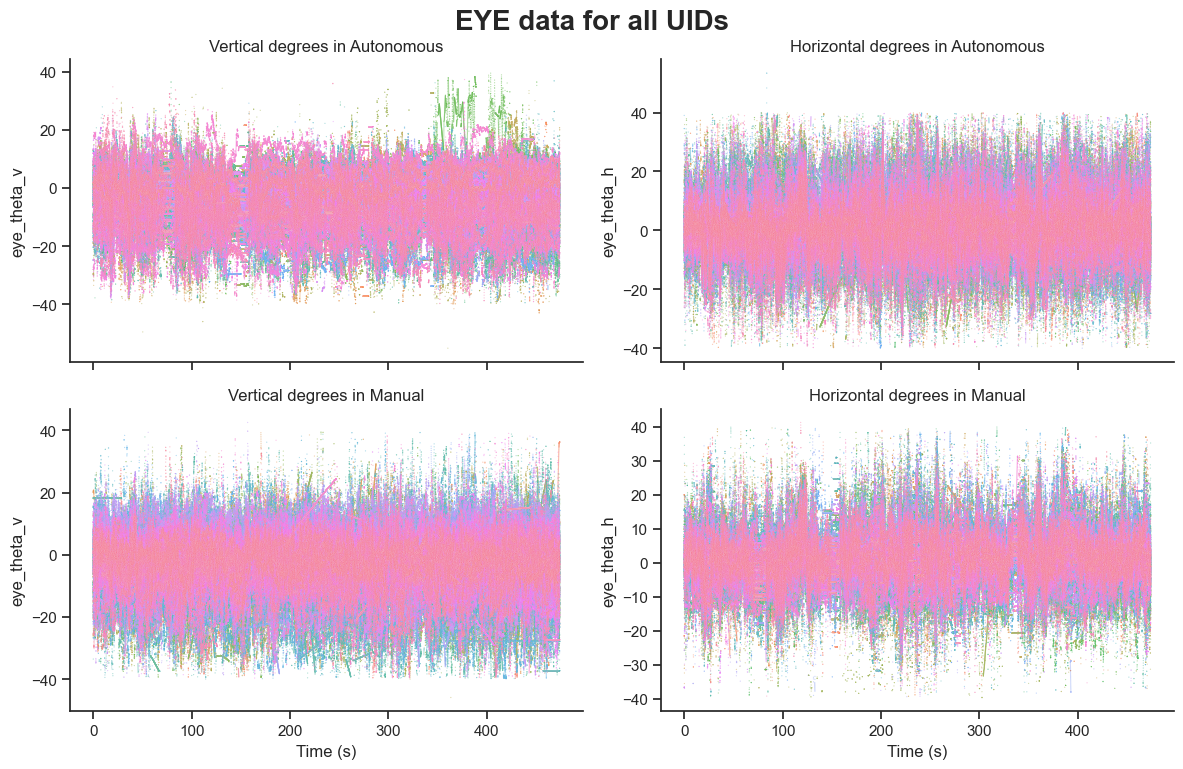

In [35]:
fig, ax = plt.subplots(2,2,figsize=(12, 8), sharex=True)
fig.suptitle("EYE data for all UIDs", fontsize=20, y=0.96, fontweight='bold')
sns.scatterplot(data=df_manual, x='Time_duration',y='eye_theta_v', hue='uid', s=0.8, alpha=0.4, ax=ax[0,0], legend=False)
ax[0,0].set_title('Vertical degrees in Autonomous')
sns.scatterplot(data=df_autonomous, x='Time_duration',y='eye_theta_v', hue='uid', s=0.8, alpha=0.4, ax=ax[1,0], legend=False)
ax[1,0].set_title('Vertical degrees in Manual')
# sns.scatterplot(data=df_manual_sample, x='Time_duration',y='CarRoll_degrees', hue='uid', s=0.8, alpha=0.4, ax=ax[2,0])
# sns.move_legend(ax[2,0], "upper right", fontsize=8)
# ax[2,0].set_title('UIDs with recording issues')
ax[1,0].set_xlabel('Time (s)')
#
sns.scatterplot(data=df_autonomous, x='Time_duration',y='eye_theta_h', hue='uid', s=0.8, alpha=0.4, ax=ax[0,1], legend=False)
ax[0,1].set_title('Horizontal degrees in Autonomous')
sns.scatterplot(data=df_manual, x='Time_duration',y='eye_theta_h', hue='uid', s=0.8, alpha=0.4, ax=ax[1,1], legend=False)
ax[1,1].set_title('Horizontal degrees in Manual')
# sns.scatterplot(data=df_excluded_uids_eye, x='Time_duration',y='eye_theta_h_degree', hue='uid', s=0.8, alpha=0.4, ax=ax[2,1])
# sns.move_legend(ax[2,1], "upper right", fontsize=8)
# ax[2,1].set_title('UIDs with recording issues')
ax[1,1].set_xlabel('Time (s)')
sns.despine()
plt.tight_layout()
format='pdf'
# plt.savefig(PLOTS_DIR / f"Eye_data_ALL_UIDs_NewAngles_.{format}", format=format, dpi=1200)
# plt.savefig(PLOTS_DIR / 'Eye_data_ALL_UIDs_NewAngles_Autonomous_Manual.png', dpi=300)

In [ ]:
fig, ax = plt.subplots(3,2,figsize=(12, 8), sharex=True)
fig.suptitle("Local HEAD data for all UIDs", fontsize=20, y=0.96, fontweight='bold')
sns.scatterplot(data=df_autonomous, x='Time_duration',y='RelativeHeadYaw_degrees', hue='uid', s=0.8, alpha=0.4, ax=ax[0,0], legend=False)
ax[0,0].set_title('Autonomous')
sns.scatterplot(data=df_autonomous, x='Time_duration',y='RelativeHeadPitch_degrees', hue='uid', s=0.8, alpha=0.4, ax=ax[1,0], legend=False)
sns.scatterplot(data=df_autonomous, x='Time_duration',y='RelativeHeadRoll_degrees', hue='uid', s=0.8, alpha=0.4, ax=ax[2,0],legend=False)
ax[2,0].set_xlabel('Time (s)')
#
sns.scatterplot(data=df_manual, x='Time_duration',y='RelativeHeadYaw_degrees', hue='uid', s=0.8, alpha=0.4, ax=ax[0,1], legend=False)
ax[0,1].set_title('Manual')
sns.scatterplot(data=df_manual, x='Time_duration',y='RelativeHeadPitch_degrees', hue='uid', s=0.8, alpha=0.4, ax=ax[1,1], legend=False)
sns.scatterplot(data=df_manual, x='Time_duration',y='RelativeHeadRoll_degrees', hue='uid', s=0.8, alpha=0.4, ax=ax[2,1],legend=False)
ax[2,1].set_xlabel('Time (s)')
sns.despine()
plt.tight_layout()
# plt.savefig(PLOTS_DIR / 'HeadLocal_data_ALL_UIDs_NewAngles_Autonomous_Manual.png', dpi=300)

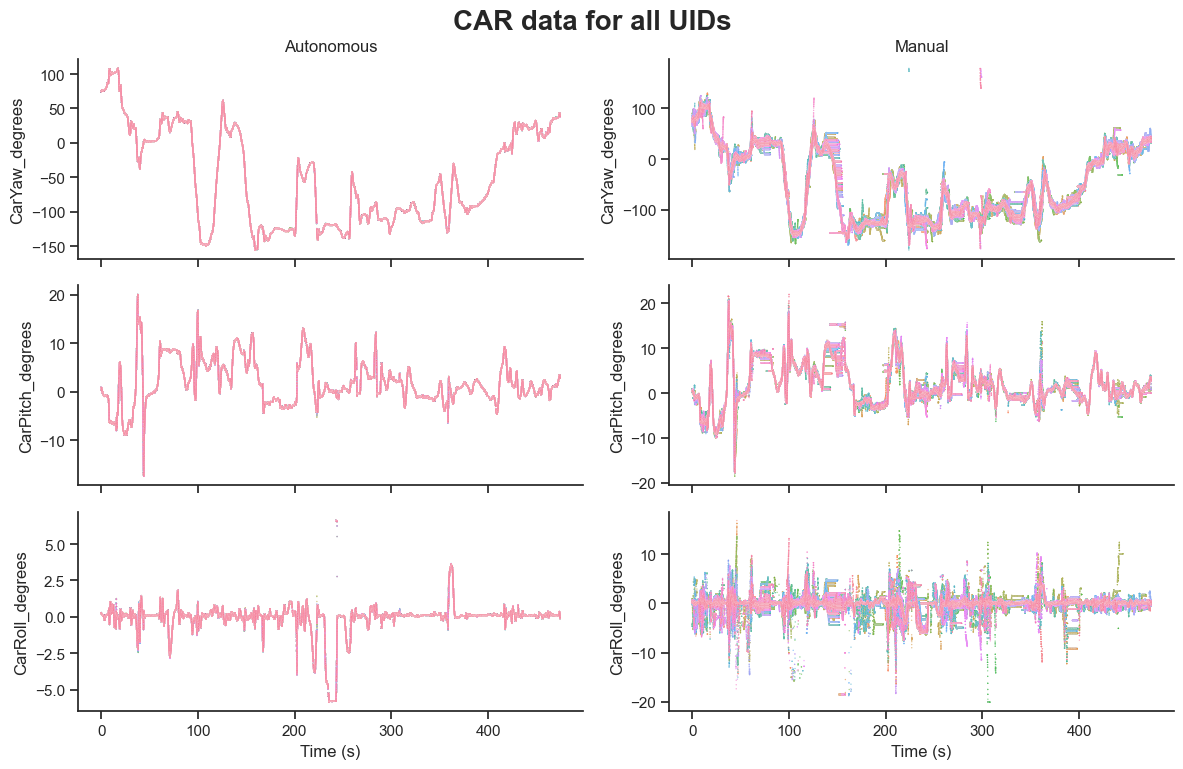

In [36]:
fig, ax = plt.subplots(3,2,figsize=(12, 8), sharex=True)
fig.suptitle("CAR data for all UIDs", fontsize=20, y=0.96, fontweight='bold')
sns.scatterplot(data=df_autonomous, x='Time_duration',y='CarYaw_degrees', hue='uid', s=1, alpha=0.6, ax=ax[0,0], legend=False)
ax[0,0].set_title('Autonomous')
sns.scatterplot(data=df_autonomous, x='Time_duration',y='CarPitch_degrees', hue='uid', s=1, alpha=0.6, ax=ax[1,0], legend=False)
sns.scatterplot(data=df_autonomous, x='Time_duration',y='CarRoll_degrees', hue='uid', s=1, alpha=0.6, ax=ax[2,0],legend=False)
ax[2,0].set_xlabel('Time (s)')
#
sns.scatterplot(data=df_manual, x='Time_duration',y='CarYaw_degrees', hue='uid', s=1, alpha=0.6, ax=ax[0,1], legend=False)
ax[0,1].set_title('Manual')
sns.scatterplot(data=df_manual, x='Time_duration',y='CarPitch_degrees', hue='uid', s=1, alpha=0.6, ax=ax[1,1], legend=False)
sns.scatterplot(data=df_manual, x='Time_duration',y='CarRoll_degrees', hue='uid', s=1, alpha=0.6, ax=ax[2,1],legend=False)
ax[2,1].set_xlabel('Time (s)')
sns.despine()
plt.tight_layout()
# plt.savefig(PLOTS_DIR / 'CarGlobal_data_ALL_UIDs_NewAngles_Autonomous_Manual.png', dpi=300)

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(10, 8), sharex=True)
fig.suptitle("Steering data for all UIDs", fontsize=20, y=0.96, fontweight='bold')
sns.scatterplot(data=df_autonomous, x='Time_duration',y='steeringDegree', hue='uid', s=0.8, alpha=0.4, ax=ax[0], legend=False)
ax[0].set_title('Steering in Autonomous')
sns.scatterplot(data=df_manual, x='Time_duration',y='steeringDegree', hue='uid', s=0.8, alpha=0.4, ax=ax[1], legend=False)
ax[1].set_title('Steering in Manual')
ax[1].set_xlabel('Time (s)')
sns.despine()
plt.tight_layout()
# plt.savefig(PLOTS_DIR / 'Steering_Pupil_data_ALL_UIDs_NewAngles_Autonomous_Manual.png', dpi=300)

<!-- # 6. Derivative of the car Yaw angles

The derivative of the car’s yaw values (expressed in degrees) does not directly represent left or right turns. The derivative of the yaw angle with respect to time represents its angular velocity (or rate of change). It tells us how fast the car is turning.
Interpreting Angular Velocity:
- A **positive angular velocity** indicates that the car is turning clockwise (right turn) when viewed from above.
- A **negative angular velocity** indicates that the car is turning counterclockwise (left turn) when viewed from above.

**Magnitude vs. Direction:**
The magnitude of the angular velocity tells us how fast the car is turning, but it doesn’t specify whether it’s a left or right turn.
To determine the direction (left or right), we need additional context or information.

**Road Alignment:**
To relate angular velocity to left or right turns with respect to the road:
Consider the road normal vector (usually pointing up, perpendicular to the road surface).
Compare the car’s forward vector (usually the Z-axis after applying yaw rotation) with the road normal.
The sign of the angle between these vectors will indicate left or right tilt relative to the road. -->

In [ ]:
# # Autonomous 
# # Convert degrees to radians
# yaw_data_radians = np.deg2rad(df_autonomous_sample['CarYaw_degrees'])
# pitch_data_radians = np.deg2rad(df_autonomous_sample['CarPitch_degrees'])
# roll_data_radians = np.deg2rad(df_autonomous_sample['CarRoll_degrees'])

# # Compute the derivative using central differences
# dx = 1.0  # Adjust the step size if needed
# df_autonomous_sample['angular_velocity_yaw'] = np.gradient(yaw_data_radians, dx)
# df_autonomous_sample['angular_velocity_pith'] = np.gradient(pitch_data_radians, dx)
# df_autonomous_sample['angular_velocity_roll'] = np.gradient(roll_data_radians, dx)

# yaw_data_radians = np.deg2rad(df_manual_sample['CarYaw_degrees'])
# pitch_data_radians = np.deg2rad(df_manual_sample['CarPitch_degrees'])
# roll_data_radians = np.deg2rad(df_manual_sample['CarRoll_degrees'])

# # Compute the derivative using central differences
# df_manual_sample['angular_velocity_yaw'] = np.gradient(yaw_data_radians, dx)
# df_manual_sample['angular_velocity_pith'] = np.gradient(pitch_data_radians, dx)
# df_manual_sample['angular_velocity_roll'] = np.gradient(roll_data_radians, dx)


In [ ]:
# fig, ax = plt.subplots(2,1,figsize=(10, 8), sharex=True)
# fig.suptitle("Derivative of the Car Yaw for 50 random UIDs", fontsize=20, y=0.96, fontweight='bold')
# sns.scatterplot(data=df_autonomous_sample, x='Time_duration',y='angular_velocity_yaw', hue='uid', s=0.8, alpha=0.4, ax=ax[0], legend=False)
# ax[0].set_title('Angular velocity of yaw in Autonomous')
# ax[0].set_ylim(-0.06,0.06)
# sns.scatterplot(data=df_manual_sample, x='Time_duration',y='angular_velocity_yaw', hue='uid', s=0.8, alpha=0.4, ax=ax[1], legend=False)
# ax[1].set_title('Angular velocity of yaw in Manual')
# ax[1].set_ylim(-0.06,0.06)
# ax[1].set_xlabel('Time (s)')
# sns.despine()
# plt.tight_layout()
# # plt.savefig(PLOTS_DIR / 'Derivative_data_50_UIDs_NewAngles.png', dpi=300)

In [ ]:
# fig, ax = plt.subplots(3,2,figsize=(12, 8), sharex=True)
# fig.suptitle("CAR data for 50 random UIDs", fontsize=20, y=0.96, fontweight='bold')
# sns.scatterplot(data=df_autonomous_sample, x='Time_duration',y='angular_velocity_yaw', hue='uid', s=1, alpha=0.6, ax=ax[0,0], legend=False)
# ax[0,0].set_title('Autonomous')
# sns.scatterplot(data=df_autonomous_sample, x='Time_duration',y='angular_velocity_pith', hue='uid', s=1, alpha=0.6, ax=ax[1,0], legend=False)
# sns.scatterplot(data=df_autonomous_sample, x='Time_duration',y='angular_velocity_roll', hue='uid', s=1, alpha=0.6, ax=ax[2,0],legend=False)
# ax[2,0].set_xlabel('Time (s)')
# #
# sns.scatterplot(data=df_manual_sample, x='Time_duration',y='angular_velocity_yaw', hue='uid', s=1, alpha=0.6, ax=ax[0,1], legend=False)
# ax[0,1].set_title('Manual')
# sns.scatterplot(data=df_manual_sample, x='Time_duration',y='angular_velocity_pith', hue='uid', s=1, alpha=0.6, ax=ax[1,1], legend=False)
# sns.scatterplot(data=df_manual_sample, x='Time_duration',y='angular_velocity_roll', hue='uid', s=1, alpha=0.6, ax=ax[2,1],legend=False)
# ax[2,1].set_xlabel('Time (s)')
# sns.despine()
# plt.tight_layout()
# plt.savefig(PLOTS_DIR / 'CarGlobal_data_50_UIDs_NewAngles.png', dpi=300)

# 6. Mahalanobis distance for multivariate outlier detection

[Detecting and treating outleirs](https://towardsdatascience.com/detecting-and-treating-outliers-in-python-part-2-3a3319ec2c33)

[Mahalanobis distance](https://www.cfholbert.com/blog/outlier_mahalanobis_distance/#:~:text=To%20identify%20outliers%2C%20the%20Mahalanobis,to%20the%20number%20of%20variables)

[M2 Quantile plots](https://stats.stackexchange.com/questions/28593/mahalanobis-distance-distribution-of-multivariate-normally-distributed-points)

[Critical Values of the Chi-Square Distribution](https://www.itl.nist.gov/div898/handbook/eda/section3/eda3674.htm)


In [41]:
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import dask.array as da
import scipy as sp
from scipy.stats import chi2
from sklearn.covariance import MinCovDet
import gc

## Robust $D^2$ and Probability Distribution

The square of the Mahalanobis distance ($D^2$) can be transformed into a probability using a chi-squared cumulative probability distribution. By converting Mahalanobis distances into probabilities, we can put the Mahalanobis distances from any number of dimensions on a common 0-1 scale that indicates the probability $P(χ^2 ≤ D^2)$ that a location has a Mahalanobis distance that is greater than would be expected by chance. This is shown below.

In [46]:
### --- Helper functions ---
### Robust Mahalonibis Distance
def robust_mahalanobis_method_dask(df, md_name='',outlier_name='', p_md_name='', cut=0.001):
    #Minimum covariance determinant
    rng = np.random.RandomState(0)
    real_cov = np.cov(df.values.T)
    
    # Calculate inverse covariance
    if df.shape[1] < 2:
        # Reshape when only one column in used (e.g., 'SteeringInput')
        X = rng.multivariate_normal(mean=np.mean(df, axis=0), cov=real_cov.reshape((1,1)), size= round(len(df) * 0.5))
        cov = MinCovDet(random_state=0).fit(X) #calculate covariance
        mcd = cov.covariance_ #robust covariance metric
        robust_mean = cov.location_  #robust mean
        inv_covmat = sp.linalg.inv(mcd) #inverse of covariance matrix
    else:
        X = rng.multivariate_normal(mean=np.mean(df, axis=0), cov=real_cov, size= round(len(df) * 0.5))
        cov = MinCovDet(random_state=0).fit(X) #calculate covariance
        mcd = cov.covariance_ #robust covariance metric
        robust_mean = cov.location_  #robust mean
        inv_covmat = sp.linalg.inv(mcd) #inverse of covariance matrix
    
    # Robust M-Distance
    x_minus_mu = df - robust_mean
    # Transform data into dask arrays
    x_minus_mu_dask = da.from_array(x_minus_mu.to_numpy(), chunks=(min(x_minus_mu.shape[0], 10000), df.shape[1]))
    mahal = da.sqrt(da.diagonal(da.dot(da.dot(x_minus_mu_dask,inv_covmat), x_minus_mu_dask.T)))
    # Calculate md
    md = mahal.compute()
    # Compute the chi-squared cumulative probability distribution to transfer the md2 into probabilities
    probability_md = 1 - chi2.cdf(md, df=df.shape[1])

    # Save md values and probabilities to df column
    md_df = pd.DataFrame({md_name:md,p_md_name:probability_md})
    # Set a Chi2 cut-off point using probability of 0.01 (99.5% Chi2 quantile)
    # Degrees of freedom (df) = number of variables
    threshold = chi2.ppf((1-cut), df=df.shape[1])
    # STD threshold, assuming 'md' contains your computed distances
    # mean_md = np.mean(md)
    # std_md = np.std(md)
    # threshold_3std = mean_md + 4 * std_md
    # Flag outliers as md > threshold
    md_df[outlier_name] = md_df[md_name] > threshold
    return md_df

# Simple mahalanobis distance
def mahalanobis(df, no_dask=True, md_name='',outlier_name=''):
    # Calculate mean 
    x_minus_mu = df - np.mean(df)
    # Calculate covariance
    cov = np.cov(df.values.T)                       
    # Calculate inverse covariance
    if df.shape[1] < 2:
        # Reshape when only one column in used (e.g., 'SteeringInput')
        inv_covmat = sp.linalg.inv(cov.reshape((1,1)))
    else:
        inv_covmat = sp.linalg.inv(cov)
    if no_dask:
        # No dask work only for individual UID
        left_term = np.dot(x_minus_mu, inv_covmat)
        mahal = np.dot(left_term, x_minus_mu.T)
        # Calculate md
        md = np.sqrt(mahal.diagonal())
    else:
        # Dask needs to be used when calculating md across conditions
        x_minus_mu_dask = da.from_array(x_minus_mu.to_numpy(), chunks=(min(x_minus_mu.shape[0], 10000), df.shape[1]))
        mahal = np.sqrt(np.diagonal(np.dot(np.dot(x_minus_mu_dask,inv_covmat), x_minus_mu_dask.T)))
        # Calculate md
        md = mahal.compute()
    # Save md values to df column
    md_df = pd.DataFrame({md_name:md})
    # Set a cut-off threshold based on the Chi2 and the degrees of freedom
    # Here we choose to be conservative and only get very extreme outliers
    threshold = chi2.ppf((1-0.001), df=df.shape[1])  # degrees of freedom = number of variables
    # Assuming 'mahalanobis_distances' contains your computed distances
    # mean_md = np.mean(md)
    # std_md = np.std(md)
    # threshold_5std = mean_md + 3 * std_md
    # Set as outliers md > threshold
    md_df[outlier_name] = md_df[md_name] > threshold
    # if md_name == 'md_car':
    #     print(C)
    return md_df

## Outlier detection pipeline
Here we use the Robust $D^2$ function to calculate outliers per UID

In [51]:
# Function to calculate outlier per participant 
def mahalanobis_per_participant(df):
    # Select unique uids
    uids = df['uid'].unique()
    # Empty df to save all md and outliers
    md_df = pd.DataFrame()

    for i, id in enumerate(uids):
        # Select the uid data subset
        df_uid = df[df['uid'].isin([id])].reset_index(drop=True)
        ## ---- EYE columns ----
        # mahalanobis distances for each data subset
        mds_eye= robust_mahalanobis_method_dask(df=df_uid[['eye_theta_h', 'eye_theta_v']], md_name='md_eye',outlier_name='eye_outlier', p_md_name='p_md_eye', cut=0.001).reset_index(drop=True)

        ## ---- HEAD columns ----
        mds_head= robust_mahalanobis_method_dask(df=df_uid[['RelativeHeadYaw_degrees','RelativeHeadPitch_degrees', 'RelativeHeadRoll_degrees']], md_name='md_head',outlier_name='head_outlier', p_md_name='p_md_head', cut=0.001).reset_index(drop=True)
        
        ## ---- CAR columns ----
        mds_car= robust_mahalanobis_method_dask(df=df_uid[['CarYaw_degrees', 'CarPitch_degrees', 'CarRoll_degrees']], md_name='md_car',outlier_name='car_outlier',p_md_name='p_md_car', cut=0.001).reset_index(drop=True)
        
        ## ---- Steering ----
        mds_steer= robust_mahalanobis_method_dask(df=df_uid[['steeringDegree']], md_name='md_steering',outlier_name='steering_outlier',p_md_name='p_md_steering', cut=0.001).reset_index(drop=True)
        ## ---- Pupil dilation ----
        mds_pupil= robust_mahalanobis_method_dask(df=df_uid[['Pupil_Dilation_mean']], md_name='md_pupil_dilation',outlier_name='pupil_dilation_outlier', p_md_name='p_md_pupil',cut=0.001).reset_index(drop=True)
        
        # save md and outlier data
        md_df = pd.concat([md_df, pd.concat([mds_eye,mds_head,mds_car,mds_steer,mds_pupil], axis=1)], ignore_index=True) 
    # Concatenate original df with calculated mahalanobis distances and outliers
    df = pd.concat([df.reset_index(drop=True), md_df.reset_index(drop=True)], axis=1)
    return df

# Function to calculate outlier per condition 
def mahalanobis_per_condition(df):
    # Select unique uids
    conditions = df['Condition'].unique()
    # Empty df to save all md and outliers
    md_df = pd.DataFrame()

    for i, condition in enumerate(conditions):
        # Select the uid data subset
        df_uid = df[df['Condition'].isin([condition])].reset_index(drop=True)
        ## ---- EYE columns ----
        # mahalanobis distances for each data subset
        mds_eye= robust_mahalanobis_method_dask(df=df_uid[['eye_theta_h', 'eye_theta_v']], md_name='md_eye_condition',outlier_name='eye_outlier_condition', p_md_name='p_md_eye_condition', cut=0.001).reset_index(drop=True)
        
        ## ---- HEAD columns ----
        mds_head= robust_mahalanobis_method_dask(df=df_uid[['RelativeHeadYaw_degrees','RelativeHeadPitch_degrees', 'RelativeHeadRoll_degrees']], md_name='md_head_condition',outlier_name='head_outlier_condition', p_md_name='p_md_head_condition', cut=0.001).reset_index(drop=True)
        
        ## ---- CAR columns ----
        mds_car= robust_mahalanobis_method_dask(df=df_uid[['CarYaw_degrees', 'CarPitch_degrees', 'CarRoll_degrees']], md_name='md_car_condition',outlier_name='car_outlier_condition', p_md_name='p_md_car_condition', cut=0.001).reset_index(drop=True)
        
        ## ---- Steering ----
        mds_steer= robust_mahalanobis_method_dask(df=df_uid[['steeringDegree']], md_name='md_steering_condition',outlier_name='steering_outlier_condition', p_md_name='p_md_steer_condition', cut=0.001).reset_index(drop=True)
        
        ## ---- Pupil dilation ----
        mds_pupil= robust_mahalanobis_method_dask(df=df_uid[['Pupil_Dilation_mean']], md_name='md_pupil_dilation_condition',outlier_name='pupil_dilation_outlier_condition', p_md_name='p_md_pupil_condition', cut=0.001).reset_index(drop=True)
        
        ## save md and outlier data
        md_df = pd.concat([md_df, pd.concat([mds_eye,mds_head,mds_car,mds_steer,mds_pupil], axis=1)], ignore_index=True) 
    ## Concatenate original df with calculated mahalanobis distances and outliers
    # df = pd.concat([df.reset_index(drop=True), md_df.reset_index(drop=True)], axis=1)
    return md_df

## Applying outlier detection

In [ ]:
# Explicitly collect garbage before running md
gc.collect() 
# Upload calculated angles if saved locally
# angles_ddf = dd.read_csv(str(ANGLES_DIR / 'EEDA_angles_Autonomous_Manual.csv'))
# angles_df = angles_ddf.compute()

### 8.4.1 $D^2$ per UID

In [ ]:
gc.collect() 
# MD per UID
mahal_uid_df = df_angles.pipe(mahalanobis_per_participant) # 30 min approx
mahal_uid_df.head()

,timestamp_REF,UnixTimeStamp,TobiiTimeStamp,HmdPosition_x,HmdPosition_y,HmdPosition_z,NoseVector_x,NoseVector_y,NoseVector_z,HmdRotation_x,...,head_outlier,md_car,p_md_car,car_outlier,md_steering,p_md_steering,steering_outlier,md_pupil_dilation,p_md_pupil,pupil_dilation_outlier
0,1970-01-01 02:56:39.665039062+00:00,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,False,1.937638,0.585450,False,0.004956,0.943874,False,0.816403,0.366234,False
1,1970-01-01 02:56:39.686523437+00:00,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,False,1.937638,0.585450,False,0.004956,0.943874,False,0.816403,0.366234,False
2,1970-01-01 02:56:39.699218750+00:00,1.634728e+09,0.0,153.296448,377.121460,432.483429,0.963857,-0.065606,0.258218,0.021512,...,False,1.937638,0.585450,False,0.004956,0.943874,False,0.816403,0.366234,False
3,1970-01-01 02:56:39.721679687+00:00,1.634728e+09,0.0,162.128281,376.970490,434.783386,0.959486,-0.065430,0.274055,0.020934,...,False,1.936015,0.585793,False,0.004956,0.943874,False,0.816403,0.366234,False
4,1970-01-01 02:56:39.743164062+00:00,1.634728e+09,0.0,162.625748,376.962219,434.915253,0.959160,-0.065371,0.275206,0.021013,...,False,1.934656,0.586079,False,0.004956,0.943874,False,0.816403,0.366234,False


In [ ]:
# OPTIONAL: Save uid outlier data
# mahal_uid_df.to_csv(OUTLIERS_DIR / "EEDA_mahalanobis_per_uid_for_all.csv", index=False)

# 9. Visualizing Outliers 
After calculating $D^2$ per UID

## 9.1 $D^2$ Probability Distribution Plots
- The $p$-value is the probability of observing a test statistic at least as extreme in a chi-squared distribution. 
- A low $p$-value, below the chosen significance level, indicates statistical significance, i.e., sufficient evidence to reject the null hypothesis. See [Wiki](https://en.wikipedia.org/wiki/Chi-squared_distribution)

In [ ]:
# In case data was saved: load calculated outliers per uid and per condition
# mahal_uid_ddf = dd.read_csv(str(OUTLIERS_DIR / 'EEDA_mahalanobis_per_uid_for_all.csv'))
# mahal_uid_df = mahal_uid_ddf.compute()

In [ ]:
mahal_uid_df.head()

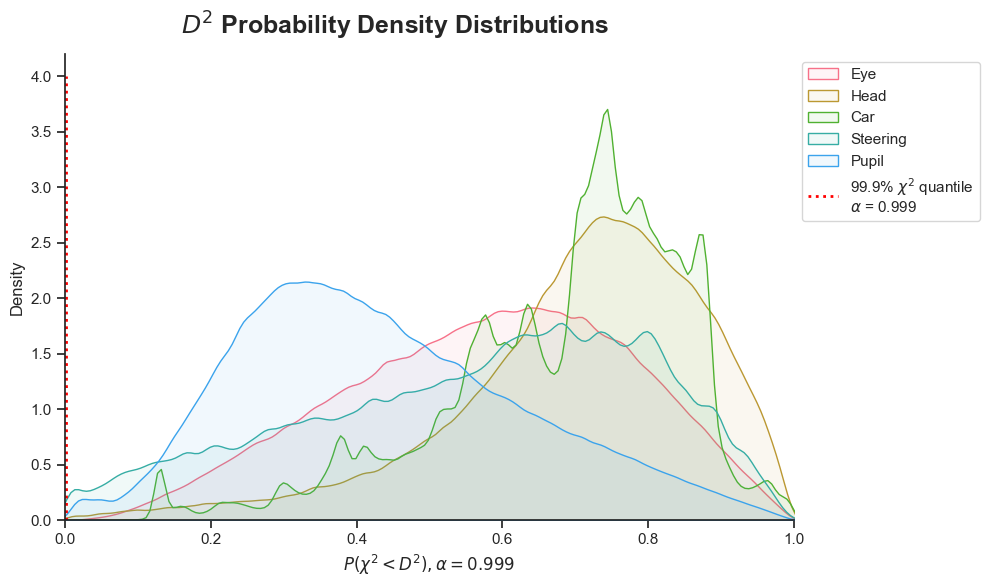

In [53]:
fig, ax = plt.subplots(figsize=(10,6), sharex=True)
fig.suptitle("$D^2$ Probability Density Distributions", fontsize=18, x=0.4, y=0.97,fontweight='bold')
sns.kdeplot(data=mahal_uid_df, x='p_md_eye', label='Eye', ax=ax, linewidth=1, fill=True, alpha=0.07).set(xlim=(0, 1))
sns.kdeplot(data=mahal_uid_df, x='p_md_head', label='Head', ax=ax, linewidth=1, fill=True, alpha=0.07)
sns.kdeplot(data=mahal_uid_df, x='p_md_car', label='Car', ax=ax, linewidth=1, fill=True, alpha=0.07)
sns.kdeplot(data=mahal_uid_df, x='p_md_steering', label='Steering', ax=ax, linewidth=1, fill=True, alpha=0.07)
sns.kdeplot(data=mahal_uid_df, x='p_md_pupil', label='Pupil', ax=ax, linewidth=1, fill=True, alpha=0.07)
# ax[1].set_title('Autonomous')
ax.set_xlabel(r'$P(\chi^2 < D^2), \alpha = 0.999$')
ax.vlines(0.001, ymax=4, ymin=0, label =r"99.9% $\chi^2$ quantile" + "\n" + r"$\alpha$ = 0.999", linestyles="dotted",linewidth=2, color='red') 
ax.legend()
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()  
fig.tight_layout()
# plt.savefig(PLOTS_DIR / 'D2_probabilities_0001_for_all.jpeg', dpi=500)
plt.show()

## 9.2 Outliers per UID at Different Quantiles
For easier visualization we used .scatter() function instead of sns.scatterplot(). Then we first separate outliers from inliers and plot them in the same subplot but with different colors.

In [ ]:
# Eye outlier
eye_uid_true = mahal_uid_df[mahal_uid_df['eye_outlier'] == True]
eye_uid_false = mahal_uid_df[mahal_uid_df['eye_outlier'] == False]
# Head outlier
head_uid_true = mahal_uid_df[mahal_uid_df['head_outlier'] == True]
head_uid_false = mahal_uid_df[mahal_uid_df['head_outlier'] == False]
# Car outlier
car_uid_true = mahal_uid_df[mahal_uid_df['car_outlier'] == True]
car_uid_false = mahal_uid_df[mahal_uid_df['car_outlier'] == False]
# Steering outlier
steer_uid_true = mahal_uid_df[mahal_uid_df['steering_outlier'] == True]
steer_uid_false = mahal_uid_df[mahal_uid_df['steering_outlier'] == False]
# Pupil outlier
pupil_uid_true = mahal_uid_df[mahal_uid_df['pupil_dilation_outlier'] == True]
pupil_uid_false = mahal_uid_df[mahal_uid_df['pupil_dilation_outlier'] == False]

In [ ]:
fig, ax = plt.subplots(5,1,figsize=(14,14), sharex=True)
# outlier colors palette
colors = {True:'#C2294C',False:'#4578AD'}
fig.suptitle("Outlier detection per uid at different $\chi^2$ quantiles", 
           fontsize=24,x=0.4, y=0.99,fontweight='bold')
## Eye
# sns.scatterplot(x=manual_df['Time_duration'],y= manual_df['md_eye'], data=manual_df, hue='eye_outlier',s=50, ax=ax[0], palette=colors, alpha=0.7)
e1 = ax[0].scatter(x=eye_uid_true['Time_duration'],y= eye_uid_true['md_eye'],s=30, color='#C2294C', alpha=0.3)
e2 = ax[0].scatter(x=eye_uid_false['Time_duration'],y= eye_uid_false['md_eye'], s=30, color='#4578AD', alpha=0.1)
# Create a separate scatter plot for the legend
legend_scatter1 = ax[0].scatter([], [], label='True', s=30, color='#C2294C', alpha=1.0)
legend_scatter2 = ax[0].scatter([], [], label='False', s=30, color='#4578AD', alpha=1.0)
ax[0].set_ylabel('$D^2$')
ax[0].set_title('Eye')
ax[0].hlines(chi2.ppf(0.975,2), 0, max(mahal_uid_df['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[0].hlines(chi2.ppf(0.99,2), 0, max(mahal_uid_df['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[0].hlines(chi2.ppf(0.999,2), 0, max(mahal_uid_df['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')
ax[0].legend(title='Outlier', bbox_to_anchor=(1.05, 1), loc='upper left')
# ## Head
# sns.scatterplot(x=manual_df['Time_duration'],y= manual_df['md_head_condition'], data=manual_df, hue='head_outlier',s=1, ax=ax[1], legend=False)
h1 = ax[1].scatter(x=head_uid_true['Time_duration'],y= head_uid_true['md_head'],s=30, color='#C2294C', alpha=0.3)
h2 = ax[1].scatter(x=head_uid_false['Time_duration'],y= head_uid_false['md_head'], s=30, color='#4578AD', alpha=0.1)
ax[1].set_ylabel('$D^2$')
ax[1].set_title('Head')
ax[1].hlines(chi2.ppf(0.975,3), 0, max(mahal_uid_df['Time_duration']), linestyles ="solid", linewidth=2, color='red') 
ax[1].hlines(chi2.ppf(0.99,3), 0, max(mahal_uid_df['Time_duration']), linestyles="dashed", linewidth=2, color='red') 
ax[1].hlines(chi2.ppf(0.999,3), 0, max(mahal_uid_df['Time_duration']), linestyles ="dotted", linewidth=2, color='red')
# # ## Car
# sns.scatterplot(x=manual_df['Time_duration'],y= manual_df['md_car'], data=manual_df, hue='car_outlier',s=1, ax=ax[2], legend=False)
c1 = ax[2].scatter(x=car_uid_true['Time_duration'],y= car_uid_true['md_car'],s=30, color='#C2294C', alpha=0.3)
c2 = ax[2].scatter(x=car_uid_false['Time_duration'],y= car_uid_false['md_car'], s=30, color='#4578AD', alpha=0.1)
ax[2].set_ylabel('$D^2$')
ax[2].set_title('Car')
ax[2].hlines(chi2.ppf(0.975,3), 0, max(mahal_uid_df['Time_duration']), linestyles ="solid", linewidth=2, color='red') 
ax[2].hlines(chi2.ppf(0.99,3), 0, max(mahal_uid_df['Time_duration']), linestyles="dashed", linewidth=2, color='red') 
ax[2].hlines(chi2.ppf(0.999,3), 0, max(mahal_uid_df['Time_duration']), linestyles ="dotted", linewidth=2, color='red')
# # ## Steering
# sns.scatterplot(x=manual_df['Time_duration'],y= manual_df['md_steering_condition'], data=manual_df, hue='steering_outlier',s=1, ax=ax[3], legend=False)
s1 = ax[3].scatter(x=steer_uid_true['Time_duration'],y= steer_uid_true['md_steering'],s=30, color='#C2294C', alpha=0.3)
s2 = ax[3].scatter(x=steer_uid_false['Time_duration'],y= steer_uid_false['md_steering'], s=30, color='#4578AD', alpha=0.1)
ax[3].set_ylabel('$D^2$')
ax[3].set_title('Steering')
ax[3].hlines(chi2.ppf(0.975,1), 0, max(mahal_uid_df['Time_duration']), linestyles ="solid", linewidth=2, color='red') 
ax[3].hlines(chi2.ppf(0.99,1), 0, max(mahal_uid_df['Time_duration']), linestyles="dashed", linewidth=2, color='red') 
ax[3].hlines(chi2.ppf(0.999,1), 0, max(mahal_uid_df['Time_duration']), linestyles ="dotted", linewidth=2, color='red')
# # ## Pupil
# sns.scatterplot(x=manual_df['Time_duration'],y= manual_df['md_pupil_dilation_condition'], data=manual_df, hue='pupil_dilation_outlier',s=1, ax=ax[4], legend=False)
p1 = ax[4].scatter(x=pupil_uid_true['Time_duration'],y= pupil_uid_true['md_pupil_dilation'],s=30, color='#C2294C', alpha=0.3)
p2 = ax[4].scatter(x=pupil_uid_false['Time_duration'],y= pupil_uid_false['md_pupil_dilation'], s=30, color='#4578AD', alpha=0.1)
ax[4].set_xlabel('Time (s)')
ax[4].set_ylabel('$D^2$')
ax[4].set_title('Pupil Dilation')
ax[4].hlines(chi2.ppf(0.975,1), 0, max(mahal_uid_df['Time_duration']), linestyles ="solid", linewidth=2, color='red') 
ax[4].hlines(chi2.ppf(0.99,1), 0, max(mahal_uid_df['Time_duration']), linestyles="dashed", linewidth=2, color='red') 
ax[4].hlines(chi2.ppf(0.999,1), 0, max(mahal_uid_df['Time_duration']), linestyles ="dotted", linewidth=2, color='red')
plt.tight_layout()
# plt.savefig(PLOTS_DIR / 'D2_probabilities_different_quantiles_0001_for_all.jpeg', dpi=500)
plt.show()

# 10. Calculating Outliers' Durations

In [ ]:
pd.options.mode.copy_on_write = True

In [ ]:
def calculate_outliers_duration(df, column_name=''):
    # Identify consecutive shifts from True to False individually per UID
    df.loc[:, "shifts"] = df.groupby("uid")[column_name].diff().ne(0).cumsum()
    # Filter rows where outlier is True
    true_df = df[df[column_name]]
    # Calculate the duration of each group of consecutive True values
    group_durations = true_df.groupby(['uid', 'shifts']).agg(
        uid=("uid", "first"),
        start_time=("Time_duration", "first"),
        end_time=("Time_duration", "last"),
        time_diff_s=("Time_duration", lambda x: x.iloc[-1] - x.iloc[0]),
        time_diff_ms = ("Time_duration", lambda x: (x.iloc[-1] - x.iloc[0]) * 1000)
    ).reset_index(drop=True)
    return group_durations

In [ ]:
# outlier_eye_uid = df_outliers_uid_condition[['uid','Time_duration','eye_outlier']]
outlier_eye_uid_durations = calculate_outliers_duration(mahal_uid_df[['uid', 'Time_duration', 'eye_outlier']], column_name='eye_outlier')
outlier_head_uid_durations = calculate_outliers_duration(mahal_uid_df[['uid', 'Time_duration', 'head_outlier']], column_name='head_outlier')
outlier_car_uid_durations = calculate_outliers_duration(mahal_uid_df[['uid', 'Time_duration', 'car_outlier']], column_name='car_outlier')
outlier_steering_uid_durations = calculate_outliers_duration(mahal_uid_df[['uid', 'Time_duration', 'steering_outlier']], column_name='steering_outlier')
outlier_pupil_uid_durations = calculate_outliers_duration(mahal_uid_df[['uid', 'Time_duration', 'pupil_dilation_outlier']], column_name='pupil_dilation_outlier')
# Concatenate row-wise
all_durations = [outlier_eye_uid_durations, outlier_head_uid_durations, outlier_car_uid_durations, outlier_steering_uid_durations, outlier_pupil_uid_durations]
all_durations_df = pd.concat(all_durations, ignore_index=True)

In [ ]:
all_durations_df

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(10,4), sharex=True)
fig.suptitle("Outlier durations after $D^2$ per UID", 
           fontsize=24, y=0.99,fontweight='bold')
sns.scatterplot(x='end_time', y='time_diff_s', data=all_durations_df,s=50,legend=False, ax=ax, color='#4578AD')
ax.hlines(np.mean(all_durations_df[['time_diff_s']]), 0, max(all_durations_df['end_time']), label ='mean duration', linestyles ="dotted", linewidth=2, color='red') 
ax.set_xlabel('Time (s)')
ax.set_ylabel('Duration (s)')
ax.legend()
sns.despine()
plt.tight_layout()

# 11. Calculating proportion of outliers

In [ ]:
# Number of outliers per data sample per UID
OL_sum = mahal_uid_df.groupby('uid')[['eye_outlier','head_outlier','car_outlier','steering_outlier','pupil_dilation_outlier']].apply(np.sum, axis=0 )
print('Number of outliers per data sample per UID:')
OL_sum

In [ ]:
# Proportion (in %) of outliers per data sample per UID
OL_proportion = mahal_uid_df.groupby('uid').agg({'eye_outlier': lambda x: round(x.sum()*100/len(x), 2),
                             'head_outlier': lambda x: round(x.sum()*100/len(x), 2),
                             'car_outlier': lambda x: round(x.sum()*100/len(x), 2),
                             'steering_outlier': lambda x: round(x.sum()*100/len(x), 2),
                             'pupil_dilation_outlier': lambda x: round(x.sum()*100/len(x), 2),}).reset_index()
print('Proportion (in %) of outliers per data sample per UID:')
OL_proportion

In [ ]:
OL_proportion[OL_proportion['head_outlier']>0]

In [ ]:
# outlier colors palette
colors = {'no':'#6E6E46','yes':'#D62534'}
fig, ax = plt.subplots(2,2, sharey=True)
fig.suptitle("Proportion (in %) of outliers", fontsize=20, y=0.96, fontweight='bold')
sns.histplot(data=OL_proportion, x='eye_outlier', color='#D62534', ax=ax[0,0])
ax[0,0].set_xlabel('eye outlier (%)')
ax[0,0].set_ylabel('UID count')
sns.histplot(data=OL_proportion, x='head_outlier', color='#D62534', ax=ax[0,1])
ax[0,1].set_xlabel('head outlier (%)')
sns.histplot(data=OL_proportion, x='steering_outlier', color='#D62534', ax=ax[1,0])
ax[1,0].set_xlabel('steering outlier (%)')
ax[1,0].set_ylabel('UID count')
sns.histplot(data=OL_proportion, x='pupil_dilation_outlier', color='#D62534', ax=ax[1,1])
ax[1,1].set_xlabel('pupil outlier (%)')
sns.despine()
plt.tight_layout()
# plt.savefig(PLOTS_DIR / 'Proportion_outliers_NEW.png', dpi=300)

In [ ]:
df_out_long = mahal_uid_df[['uid','Condition','eye_outlier','head_outlier','car_outlier','steering_outlier','pupil_dilation_outlier']].melt(['Condition', 'uid'], var_name='sample_name', value_name='sample_value')
df_out_long

In [ ]:
df_out_long['outlier'] = df_out_long.apply(lambda x: 'yes' if x['sample_value'] == True else 'no', axis=1)
df_out_long['All_data'] = df_out_long.apply(lambda x: 'all' if x['sample_value'] == False else '', axis=1)
df_out_long

In [ ]:
# replace conditions to numbers
label_mapping = {'eye_outlier': 'eye', 'car_outlier': 'car','head_outlier': 'head','pupil_dilation_outlier': 'pupil','steering_outlier': 'steering'}
df_out_long['sample_name'] = df_out_long['sample_name'].map(label_mapping)

In [ ]:
new_df = df_out_long.groupby('sample_name')['outlier'].value_counts(normalize=True)
new_df1 = new_df.mul(100).rename('Percent').reset_index()
new_df1

In [ ]:
new_df2 = df_out_long.groupby('All_data')['outlier'].value_counts(normalize=True)
new_df3 = new_df2.mul(100).rename('Percent').reset_index()
new_df3

In [ ]:
%matplotlib inline
g = sns.displot(df_out_long, x='sample_name', hue='outlier', multiple='stack', stat='proportion',palette=colors, height=4, aspect=1.5, shrink=0.6)
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
# plt.show()
# plt.savefig(PLOTS_DIR / 'Proportion_outliers_per_sample_NEW.png', dpi=300)

In [ ]:
g1_2 = sns.displot(df_out_long, x='sample_name', hue='outlier', col='Condition', multiple='stack', stat='proportion',palette=colors, height=4, aspect=1, shrink=0.9)
for ax in g1_2.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
# plt.show()
# plt.savefig(PLOTS_DIR / 'Proportion_outliers_per_sample_condition_new.png', dpi=300)

In [ ]:
g2 = sns.displot(df_out_long, x='Condition', hue='outlier', multiple='stack', stat='proportion',palette=colors, shrink=.6, height=4, aspect=.9)
for ax in g2.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
# plt.savefig(PLOTS_DIR / 'Proportion_outliers_condition_NEW.png', dpi=300)
# plt.show()

In [ ]:
df_out_long

In [ ]:
# Calculate total percentage of outliers in data
print(f'Total outliers in dataset:')
new_df_all = df_out_long.groupby('All_data')['outlier'].value_counts(normalize=True)
new_df_all
# new_df_all2 = new_df_all.mul(100).rename('Percent').reset_index()
# new_df_all2

In [ ]:
%matplotlib inline
g3 = sns.displot(df_out_long, x='All_data', hue='outlier', multiple='stack', stat='proportion',palette=colors, shrink=.1, height=4, aspect=.6)
for ax in g3.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
# plt.show()
# plt.savefig(PLOTS_DIR / 'Proportion_outliers_all.png', dpi=300)

# 12. Interpolate outlier per uid

In [ ]:
mahal_uid_df.columns

In [ ]:
pd.options.mode.copy_on_write = True
def interpolate_nan_values_uid(df):
    # 1. Convert 'outlier' column values to NaN where True
    # -- Eye
    df.loc[df['eye_outlier'], ['eye_theta_h', 'eye_theta_v']] = np.nan
    # -- Head
    df.loc[df['head_outlier'], ['RelativeHeadYaw_degrees', 'RelativeHeadPitch_degrees','RelativeHeadRoll_degrees']] = np.nan
    # -- Car
    df.loc[df['car_outlier'], ['CarRoll_degrees','CarYaw_degrees', 'CarPitch_degrees']] = np.nan
    # -- Steering
    df.loc[df['steering_outlier'], ['steeringDegree']] = np.nan
    # -- Pupil
    df.loc[df['pupil_dilation_outlier'], ['Pupil_Dilation_mean']] = np.nan
    
    # Group by 'uid' and interpolate NaN values
    interpolated_df = df.groupby('uid').apply(lambda group: group.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()).reset_index(drop=True)
    return interpolated_df

In [ ]:
mahal_uid_df[['RelativeHeadRoll_degrees','RelativeHeadPitch_degrees','RelativeHeadYaw_degrees']].isna().sum()

In [ ]:
# simple linear interpolation on nan
df_mahal_interpolated = interpolate_nan_values_uid(mahal_uid_df)
# save calculated md
# df_mahal_interpolated.to_csv("data/EEDA_mahalanobis_per_uid_interpolated.csv",index=False)

# 13. Calculate $D^2$ per conditions

In [ ]:
# Load interpolated outliers per uid
ddf_mahal_interpolated = dd.read_csv(str(OUTLIERS_DIR / 'EEDA_mahalanobis_per_uid_interpolated.csv'))
df_mahal_interpolated = ddf_mahal_interpolated.compute()

In [ ]:
gc.collect() 
# MD per UID
mahal_per_condition_df = df_mahal_interpolated.pipe(mahalanobis_per_condition)
# Save MD per conditions
# mahal_per_condition_df.to_csv(OUTLIERS_DIR / "EEDA_mahalanobis_per_condition_0001.csv", index=False)
mahal_per_condition_df.head()

In [ ]:
# Load calculated outliers per condition
mahal_per_condition_ddf = dd.read_csv(str(OUTLIERS_DIR / 'EEDA_mahalanobis_per_condition_0001_renamed.csv'))
mahal_per_condition_df = mahal_per_condition_ddf.compute()

In [ ]:
mahal_per_condition_df.columns

In [ ]:
# concatenate interpolated data after outlier per uid with outlier per condition
mahal_uid_condition_df = pd.concat([df_mahal_interpolated.reset_index(drop=True), mahal_per_condition_df.reset_index(drop=True)], ignore_index=False,axis=1)

In [ ]:
mahal_uid_condition_df

In [ ]:
# True and False EYE data per condition
eye_manual_true_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Manual')&(mahal_uid_condition_df['eye_outlier_condition'] == True)]
eye_manual_false_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Manual')&(mahal_uid_condition_df['eye_outlier_condition'] == False)]
eye_autonomous_true_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Autonomous')&(mahal_uid_condition_df['eye_outlier_condition'] == True)]
eye_autonomous_false_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Autonomous')&(mahal_uid_condition_df['eye_outlier_condition'] == False)]

# True and False HEAD data per condition
head_manual_true_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Manual')&(mahal_uid_condition_df['head_outlier_condition'] == True)]
head_manual_false_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Manual')&(mahal_uid_condition_df['head_outlier_condition'] == False)]
head_autonomous_true_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Autonomous')&(mahal_uid_condition_df['head_outlier_condition'] == True)]
head_autonomous_false_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Autonomous')&(mahal_uid_condition_df['head_outlier_condition'] == False)]

# True and False HEAD data per condition
car_manual_true_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Manual')&(mahal_uid_condition_df['car_outlier_condition'] == True)]
car_manual_false_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Manual')&(mahal_uid_condition_df['car_outlier_condition'] == False)]
car_autonomous_true_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Autonomous')&(mahal_uid_condition_df['car_outlier_condition'] == True)]
car_autonomous_false_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Autonomous')&(mahal_uid_condition_df['car_outlier_condition'] == False)]

# True and False STEERING data per condition
steering_manual_true_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Manual')&(mahal_uid_condition_df['steering_outlier_condition'] == True)]
steering_manual_false_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Manual')&(mahal_uid_condition_df['steering_outlier_condition'] == False)]
steering_autonomous_true_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Autonomous')&(mahal_uid_condition_df['steering_outlier_condition'] == True)]
steering_autonomous_false_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Autonomous')&(mahal_uid_condition_df['steering_outlier_condition'] == False)]

# True and False PUPIL data per condition
pupil_manual_true_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Manual')&(mahal_uid_condition_df['pupil_dilation_outlier_condition'] == True)]
pupil_manual_false_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Manual')&(mahal_uid_condition_df['pupil_dilation_outlier_condition'] == False)]
pupil_autonomous_true_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Autonomous')&(mahal_uid_condition_df['pupil_dilation_outlier_condition'] == True)]
pupil_autonomous_false_condition = mahal_uid_condition_df[(mahal_uid_condition_df['Condition']=='Autonomous')&(mahal_uid_condition_df['pupil_dilation_outlier_condition'] == False)]

In [ ]:
fig, ax = plt.subplots(5,2,figsize=(14,14), sharex=True)
# outlier colors palette
colors = {True:'#C2294C',False:'#4578AD'}
fig.suptitle("Outlier detection per condition at different $\chi^2$ quantiles", 
           fontsize=24,x=0.4, y=0.99,fontweight='bold')
## EYE MANUAL
# sns.scatterplot(x=manual_df['Time_duration'],y= manual_df['md_eye'], data=manual_df, hue='eye_outlier',s=50, ax=ax[0], palette=colors, alpha=0.7)
e1 = ax[0,0].scatter(x=eye_manual_true_condition['Time_duration'],y= eye_manual_true_condition['md_eye_condition'],s=30, color='#C2294C', alpha=0.3)
e2 = ax[0,0].scatter(x=eye_manual_false_condition['Time_duration'],y= eye_manual_false_condition['md_eye_condition'], s=30, color='#4578AD', alpha=0.1)
ax[0,0].set_ylabel('Eye $D^2$')
ax[0,0].set_title('Manual')
ax[0,0].hlines(chi2.ppf(0.975,2), 0, max(df_mahal_interpolated['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[0,0].hlines(chi2.ppf(0.99,2), 0, max(df_mahal_interpolated['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[0,0].hlines(chi2.ppf(0.999,2), 0, max(df_mahal_interpolated['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')

## EYE AUTONOMOUS
e01 = ax[0,1].scatter(x=eye_autonomous_true_condition['Time_duration'],y= eye_autonomous_true_condition['md_eye_condition'],s=30, color='#C2294C', alpha=0.3)
e02 = ax[0,1].scatter(x=eye_autonomous_false_condition['Time_duration'],y= eye_autonomous_false_condition['md_eye_condition'], s=30, color='#4578AD', alpha=0.1)

# Create a separate scatter plot for the legend
legend_scatter1 = ax[0,1].scatter([], [], label='True', s=30, color='#C2294C', alpha=1.0)
legend_scatter2 = ax[0,1].scatter([], [], label='False', s=30, color='#4578AD', alpha=1.0)
ax[0,1].set_title('Autonomous')
ax[0,1].hlines(chi2.ppf(0.975,2), 0, max(df_mahal_interpolated['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[0,1].hlines(chi2.ppf(0.99,2), 0, max(df_mahal_interpolated['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[0,1].hlines(chi2.ppf(0.999,2), 0, max(df_mahal_interpolated['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')
ax[0,1].legend(title='Outlier', bbox_to_anchor=(1.05, 1), loc='upper left')

## HEAD MANUAL
# sns.scatterplot(x=manual_df['Time_duration'],y= manual_df['md_eye'], data=manual_df, hue='eye_outlier',s=50, ax=ax[0], palette=colors, alpha=0.7)
e1 = ax[1,0].scatter(x=head_manual_true_condition['Time_duration'],y= head_manual_true_condition['md_head_condition'],s=30, color='#C2294C', alpha=0.3)
e2 = ax[1,0].scatter(x=head_manual_false_condition['Time_duration'],y= head_manual_false_condition['md_head_condition'], s=30, color='#4578AD', alpha=0.1)
ax[1,0].set_ylabel('Head $D^2$')
# ax[1,0].set_title('Manual')
ax[1,0].hlines(chi2.ppf(0.975,3), 0, max(df_mahal_interpolated['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[1,0].hlines(chi2.ppf(0.99,3), 0, max(df_mahal_interpolated['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[1,0].hlines(chi2.ppf(0.999,3), 0, max(df_mahal_interpolated['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')

## HEAD AUTONOMOUS
e01 = ax[1,1].scatter(x=head_autonomous_true_condition['Time_duration'],y= head_autonomous_true_condition['md_head_condition'],s=30, color='#C2294C', alpha=0.3)
e02 = ax[1,1].scatter(x=head_autonomous_false_condition['Time_duration'],y= head_autonomous_false_condition['md_head_condition'], s=30, color='#4578AD', alpha=0.1)

# ax[1,1].set_title('Head Autonomous')
ax[1,1].hlines(chi2.ppf(0.975,3), 0, max(df_mahal_interpolated['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[1,1].hlines(chi2.ppf(0.99,3), 0, max(df_mahal_interpolated['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[1,1].hlines(chi2.ppf(0.999,3), 0, max(df_mahal_interpolated['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')

## CAR MANUAL
e1 = ax[2,0].scatter(x=car_manual_true_condition['Time_duration'],y= car_manual_true_condition['md_car_condition'],s=30, color='#C2294C', alpha=0.3)
e2 = ax[2,0].scatter(x=car_manual_false_condition['Time_duration'],y= car_manual_false_condition['md_car_condition'], s=30, color='#4578AD', alpha=0.1)
ax[2,0].set_ylabel('Car $D^2$')
# ax[2,0].set_title('Car Manual')
ax[2,0].hlines(chi2.ppf(0.975,3), 0, max(df_mahal_interpolated['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[2,0].hlines(chi2.ppf(0.99,3), 0, max(df_mahal_interpolated['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[2,0].hlines(chi2.ppf(0.999,3), 0, max(df_mahal_interpolated['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')

## CAR AUTONOMOUS
e01 = ax[2,1].scatter(x=car_autonomous_true_condition['Time_duration'],y= car_autonomous_true_condition['md_car_condition'],s=30, color='#C2294C', alpha=0.3)
e02 = ax[2,1].scatter(x=car_autonomous_false_condition['Time_duration'],y= car_autonomous_false_condition['md_car_condition'], s=30, color='#4578AD', alpha=0.1)

# ax[2,1].set_title('Car Autonomous')
ax[2,1].hlines(chi2.ppf(0.975,3), 0, max(df_mahal_interpolated['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[2,1].hlines(chi2.ppf(0.99,3), 0, max(df_mahal_interpolated['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[2,1].hlines(chi2.ppf(0.999,3), 0, max(df_mahal_interpolated['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')

## STEERING MANUAL
e1 = ax[3,0].scatter(x=steering_manual_true_condition['Time_duration'],y= steering_manual_true_condition['md_steering_condition'],s=30, color='#C2294C', alpha=0.3)
e2 = ax[3,0].scatter(x=steering_manual_false_condition['Time_duration'],y= steering_manual_false_condition['md_steering_condition'], s=30, color='#4578AD', alpha=0.1)
ax[3,0].set_ylabel('Steering $D^2$')
# ax[3,0].set_title('Steering Manual')
ax[3,0].hlines(chi2.ppf(0.975,1), 0, max(df_mahal_interpolated['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[3,0].hlines(chi2.ppf(0.99,1), 0, max(df_mahal_interpolated['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[3,0].hlines(chi2.ppf(0.999,1), 0, max(df_mahal_interpolated['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')

## STEERING AUTONOMOUS
e01 = ax[3,1].scatter(x=steering_autonomous_true_condition['Time_duration'],y= steering_autonomous_true_condition['md_steering_condition'],s=30, color='#C2294C', alpha=0.3)
e02 = ax[3,1].scatter(x=steering_autonomous_false_condition['Time_duration'],y= steering_autonomous_false_condition['md_steering_condition'], s=30, color='#4578AD', alpha=0.1)

# ax[3,1].set_title('Steering Autonomous')
ax[3,1].hlines(chi2.ppf(0.975,1), 0, max(df_mahal_interpolated['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[3,1].hlines(chi2.ppf(0.99,1), 0, max(df_mahal_interpolated['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[3,1].hlines(chi2.ppf(0.999,1), 0, max(df_mahal_interpolated['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')

## PUPIL MANUAL
e1 = ax[4,0].scatter(x=pupil_manual_true_condition['Time_duration'],y= pupil_manual_true_condition['md_pupil_dilation_condition'],s=30, color='#C2294C', alpha=0.3)
e2 = ax[4,0].scatter(x=pupil_manual_false_condition['Time_duration'],y= pupil_manual_false_condition['md_pupil_dilation_condition'], s=30, color='#4578AD', alpha=0.1)
ax[4,0].set_ylabel('Pupil Dilation $D^2$')
# ax[4,0].set_title('Pupil Dilation Manual')
ax[4,0].hlines(chi2.ppf(0.975,1), 0, max(df_mahal_interpolated['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[4,0].hlines(chi2.ppf(0.99,1), 0, max(df_mahal_interpolated['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[4,0].hlines(chi2.ppf(0.999,1), 0, max(df_mahal_interpolated['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')

## PUPIL AUTONOMOUS
e01 = ax[4,1].scatter(x=pupil_autonomous_true_condition['Time_duration'],y= pupil_autonomous_true_condition['md_pupil_dilation_condition'],s=30, color='#C2294C', alpha=0.3)
e02 = ax[4,1].scatter(x=pupil_autonomous_false_condition['Time_duration'],y= pupil_autonomous_false_condition['md_pupil_dilation_condition'], s=30, color='#4578AD', alpha=0.1)

# ax[4,1].set_title('Pupil Dilation Autonomous')
ax[4,1].hlines(chi2.ppf(0.975,1), 0, max(df_mahal_interpolated['Time_duration']), label ="97.5% $\chi^2$ quantile", linestyles ="solid", linewidth=2, color='red') 
ax[4,1].hlines(chi2.ppf(0.99,1), 0, max(df_mahal_interpolated['Time_duration']), label ="99.0% $\chi^2$ quantile", linestyles="dashed", linewidth=2, color='red') 
ax[4,1].hlines(chi2.ppf(0.999,1), 0, max(df_mahal_interpolated['Time_duration']), label ="99.9% $\chi^2$ quantile", linestyles ="dotted", linewidth=2, color='red')
sns.despine()
plt.tight_layout()
# plt.savefig(PLOTS_DIR / 'D2_quantiles_at_0001_for_all.jpeg', dpi=500)
plt.show()

In [ ]:
fig, ax = plt.subplots(3,2,figsize=(12,8), sharex=True)
fig.suptitle(r'Head Outlier per Condition, $\alpha = 0.999$', fontsize=20, y=0.97,fontweight='bold')
#### Manual plots 
h01 = ax[0,1].scatter(head_manual_false_condition['Time_duration'], head_manual_false_condition['RelativeHeadYaw_degrees'], color='#4578AD', s=1, alpha=0.1)
h02 = ax[0,1].scatter(head_manual_true_condition['Time_duration'], head_manual_true_condition['RelativeHeadYaw_degrees'], color='#C2294C', s=3, alpha=0.5)
ax[0,1].set_title('Manual')
ax[0,1].set_ylabel('Head Yaw Degrees')
ax[0,1].set_xlim(0, max(head_manual_false_condition['Time_duration']))
# Create a separate scatter plot for the legend
legend_scatter1 = ax[0,1].scatter([], [], label='True', s=30, color='#C2294C', alpha=1.0)
legend_scatter2 = ax[0,1].scatter([], [], label='False', s=30, color='#4578AD', alpha=1.0)
ax[0,1].legend(title='Outlier', bbox_to_anchor=(1.05, 1), loc='upper left')

ax[1,1].scatter(head_manual_false_condition['Time_duration'], head_manual_false_condition['RelativeHeadPitch_degrees'], label='Inlier', color='#4578AD', s=1,alpha=0.1)
ax[1,1].scatter(head_manual_true_condition['Time_duration'], head_manual_true_condition['RelativeHeadPitch_degrees'], label='Outlier', color='#C2294C', s=3, alpha=0.5)
ax[1,1].set_xlim(0, max(head_manual_false_condition['Time_duration']))
ax[1,1].set_ylabel('Head Pitch Degrees')

ax[2,1].scatter(head_manual_false_condition['Time_duration'], head_manual_false_condition['RelativeHeadRoll_degrees'], label='Inlier', color='#4578AD', s=1, alpha=0.1)
ax[2,1].scatter(head_manual_true_condition['Time_duration'], head_manual_true_condition['RelativeHeadRoll_degrees'], label='Outlier', color='#C2294C', s=3, alpha=0.5)
ax[2,1].set_xlim(0, max(head_manual_false_condition['Time_duration']))
ax[2,1].set_ylabel('Head Roll Degrees')
ax[2,1].set_xlabel('Time (s)')

#### Autonomous plots 
ax[0,0].scatter(head_autonomous_false_condition['Time_duration'], head_autonomous_false_condition['RelativeHeadYaw_degrees'], label='Inlier', color='#4578AD', s=1, alpha=0.1)
ax[0,0].scatter(head_autonomous_true_condition['Time_duration'], head_autonomous_true_condition['RelativeHeadYaw_degrees'], label='Outlier', color='#C2294C', s=3, alpha=0.5)
ax[0,0].set_title('Autonomous')
ax[0,0].set_xlim(0, max(head_manual_false_condition['Time_duration']))
ax[0,0].set_ylabel('Head Yaw Degrees')

ax[1,0].scatter(head_autonomous_false_condition['Time_duration'], head_autonomous_false_condition['RelativeHeadPitch_degrees'], label='Inlier', color='#4578AD', s=1, alpha=0.1)
ax[1,0].scatter(head_autonomous_true_condition['Time_duration'], head_autonomous_true_condition['RelativeHeadPitch_degrees'], label='Outlier', color='#C2294C', s=3, alpha=0.5)
ax[1,0].set_xlim(0, max(head_autonomous_false_condition['Time_duration']))
ax[1,0].set_ylabel('Head Pitch Degrees')
 
ax[2,0].scatter(head_autonomous_false_condition['Time_duration'], head_autonomous_false_condition['RelativeHeadRoll_degrees'], label='Inlier', color='#4578AD', s=1, alpha=0.1)
ax[2,0].scatter(head_autonomous_true_condition['Time_duration'], head_autonomous_true_condition['RelativeHeadRoll_degrees'], label='Outlier', color='#C2294C', s=3, alpha=0.5)
ax[2,0].set_xlim(0, max(head_autonomous_false_condition['Time_duration']))
ax[2,0].set_xlabel('Time (s)')
ax[2,0].set_ylabel('Head Roll Degrees')
sns.despine()
plt.tight_layout()
# plt.savefig(PLOTS_DIR / 'Head_outliers_condition_at_0001_for_all.jpeg', dpi=500)
plt.show()

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
fig.suptitle(r'Eye Outlier per Condition, $\alpha = 0.999$', fontsize=20, y=0.97,fontweight='bold')
# Autonomous
ax[0].scatter(eye_autonomous_false_condition['eye_theta_v'], eye_autonomous_false_condition['eye_theta_h'], label='Inlier', color='#4578AD', s=1, alpha=0.1)
ax[0].scatter(eye_autonomous_true_condition['eye_theta_v'], eye_autonomous_true_condition['eye_theta_h'], label='Outlier', color='#C2294C', s=3, alpha=0.5)
ax[0].set_title('Autonomous')
ax[0].set_ylabel('Eye Vertical Degrees')

# Manual
ax[1].scatter(eye_manual_false_condition['eye_theta_v'], eye_manual_false_condition['eye_theta_h'], label='Inlier', color='#4578AD', s=1, alpha=0.1)
ax[1].scatter(eye_manual_true_condition['eye_theta_v'], eye_manual_true_condition['eye_theta_h'], label='Outlier', color='#C2294C', s=3, alpha=0.5)
ax[1].set_title('Manual')
ax[1].set_ylabel('Eye Horizontal Degrees')
sns.despine()
plt.tight_layout()
# plt.savefig(PLOTS_DIR / 'Eye_outliers_condition_at_0001_for_all.jpeg', dpi=500)
plt.show()

## 13.1 Interpolate outlier per condition

In [ ]:
mahal_uid_condition_df.columns

In [ ]:
def interpolate_nan_values_condition(df):
    # 1. Convert 'outlier' column values to NaN where True
    # -- Eye
    df.loc[df['eye_outlier_condition'], ['eye_theta_h', 'eye_theta_v']] = np.nan
    # -- Head
    df.loc[df['head_outlier_condition'], ['RelativeHeadYaw_degrees', 'RelativeHeadPitch_degrees','RelativeHeadRoll_degrees']] = np.nan
    # -- Car
    df.loc[df['car_outlier_condition'], ['CarRoll_degrees','CarYaw_degrees', 'CarPitch_degrees']] = np.nan
    # -- Steering
    df.loc[df['steering_outlier_condition'], ['steeringDegree']] = np.nan
    # -- Pupil
    df.loc[df['pupil_dilation_outlier_condition'], ['Pupil_Dilation_mean']] = np.nan
    
    # Group by 'uid' and interpolate NaN values
    interpolated_df = df.groupby('uid').apply(lambda group: group.infer_objects(copy=False).interpolate(method='linear').ffill().bfill()).reset_index(drop=True)
    return interpolated_df

In [ ]:
interpolated_df1 = interpolate_nan_values_condition(mahal_uid_condition_df)

In [ ]:
interpolated_df1.isna().sum()

In [ ]:
# Save cleaned dataframe
interpolated_df1.to_csv("data/EEDA_cleaned.csv",index=False)

In [ ]:
# Interpolation small sample
# def interpolate_nan_values(df):
#     # Convert 'oulier' column values to NaN where True
#     df.loc[df['oulier'], ['position.x', 'position.y', 'position.z']] = np.nan
#     
#     # Group by 'uid' and interpolate NaN values
#     df_grouped = df.groupby('uid').apply(lambda group: group.interpolate(method='linear').ffill().bfill().infer_objects(copy=False)).reset_index(drop=True)
#     
#     return df_grouped
# 
# # Example usage:
# data = pd.DataFrame({
#     'uid': [1, 1,1, 2, 2, 3, 3],
#     'position.x': [10, 20,35, 30, 40, 50, 60],
#     'position.y': [15, 25,45, 35, 45, 55, 65],
#     'position.z': [12, 22,32, 32, 42, 52, 62],
#     'oulier': [False, True, False,False, False, True, False]
# })
# print(data)
# result_df = interpolate_nan_values(data)
# result_df

## 13.2 Visualizing data after outlier interpolation

In [ ]:
head_manual_interpolated = interpolated_df1[interpolated_df1['Condition']=='Manual']
head_autonomous_interpolated = interpolated_df1[interpolated_df1['Condition']=='Autonomous']

In [ ]:
fig, ax = plt.subplots(3,2,figsize=(12,8), sharex=True)
fig.suptitle(r'Head Data After Interpolation per Condition, $\alpha = 0.999$', fontsize=20, y=0.97,fontweight='bold')
#### Manual plots 
h01 = ax[0,1].scatter(head_manual_interpolated['Time_duration'], head_manual_interpolated['RelativeHeadYaw_degrees'], color='#4578AD', s=1, alpha=0.1)
ax[0,1].set_title('Manual')
ax[0,1].set_ylabel('Head Yaw Degrees')
ax[0,1].set_xlim(0, max(head_manual_interpolated['Time_duration']))
# Create a separate scatter plot for the legend
legend_scatter1 = ax[0,1].scatter([], [], label='True', s=30, color='#C2294C', alpha=1.0)
legend_scatter2 = ax[0,1].scatter([], [], label='False', s=30, color='#4578AD', alpha=1.0)
ax[0,1].legend(title='Outlier', bbox_to_anchor=(1.05, 1), loc='upper left')

ax[1,1].scatter(head_manual_interpolated['Time_duration'], head_manual_interpolated['RelativeHeadPitch_degrees'], label='Inlier', color='#4578AD', s=1,alpha=0.1)
ax[1,1].set_xlim(0, max(head_manual_interpolated['Time_duration']))
ax[1,1].set_ylabel('Head Pitch Degrees')

ax[2,1].scatter(head_manual_interpolated['Time_duration'], head_manual_interpolated['RelativeHeadRoll_degrees'], label='Inlier', color='#4578AD', s=1, alpha=0.1)

ax[2,1].set_xlim(0, max(head_manual_interpolated['Time_duration']))
ax[2,1].set_ylabel('Head Roll Degrees')
ax[2,1].set_xlabel('Time (s)')

#### Autonomous plots 
ax[0,0].scatter(head_autonomous_interpolated['Time_duration'], head_autonomous_interpolated['RelativeHeadYaw_degrees'], label='Inlier', color='#4578AD', s=1, alpha=0.1)
ax[0,0].set_title('Autonomous')
ax[0,0].set_xlim(0, max(head_autonomous_interpolated['Time_duration']))
ax[0,0].set_ylabel('Head Yaw Degrees')

ax[1,0].scatter(head_autonomous_interpolated['Time_duration'], head_autonomous_interpolated['RelativeHeadPitch_degrees'], label='Inlier', color='#4578AD', s=1, alpha=0.1)
ax[1,0].set_xlim(0, max(head_autonomous_interpolated['Time_duration']))
ax[1,0].set_ylabel('Head Pitch Degrees')
 
ax[2,0].scatter(head_autonomous_interpolated['Time_duration'], head_autonomous_interpolated['RelativeHeadRoll_degrees'], label='Inlier', color='#4578AD', s=1, alpha=0.1)
ax[2,0].set_xlim(0, max(head_autonomous_interpolated['Time_duration']))
ax[2,0].set_xlabel('Time (s)')
ax[2,0].set_ylabel('Head Roll Degrees')
sns.despine()
plt.tight_layout()
# plt.savefig(PLOTS_DIR / 'Head_interpolated_condition_at_0001_for_all.jpeg', dpi=500)
plt.show()